# B25 - Evaluation metrics Notebook

This notebook explores the demographics, dwell, footfall and sales data to provide a report and Tableau dahboards to the Bradford25 team.

In [566]:
pip install matplotlib geopandas numpy scipy folium plotly

Note: you may need to restart the kernel to use updated packages.


In [567]:
#Import packages
import pandas as pd
import seaborn as sns
import matplotlib
import matplotlib.pyplot as plt
import geopandas as gpd
import numpy as np

## Combining the demographics, dwell, footfall and sales data of the 13 areas provided - for 2025

In [570]:
import glob
import os

#Folder with containing all areas
folder_path = r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Data 2025"

#Find all CSVs in all subfolders
area_folders = glob.glob(os.path.join(folder_path, '*'))

#Define file names
custom_names = ['demographics', 'dwell', 'footfall', 'sales']

#Dict to store combined dataframes by file type
combined = {name: pd.DataFrame() for name in custom_names}

for area_path in area_folders:
    #Get area name
    area_name = os.path.basename(area_path)
    
    csv_files = sorted(glob.glob(os.path.join(area_path, '*.csv')))
    
    #Loop over CSVs and assign new name
    for i, file in enumerate (csv_files):
        df = pd.read_csv(file, encoding='cp1252')
        
        #Add area column
        df['region'] = area_name
        
        #Get the new names
        new_name = custom_names[i]
        
        #Concatenate into 
        combined[new_name] = pd.concat([combined[new_name], df], ignore_index=True)

#Check
print(combined['demographics'].head())

       area         Category  Group  Value  \
0  Bradford  Age (Residents)   0-14  29.0%   
1  Bradford  Age (Residents)  15-29  23.3%   
2  Bradford  Age (Residents)  30-44  23.2%   
3  Bradford  Age (Residents)  45-59  13.3%   
4  Bradford  Age (Residents)    60+  11.2%   

                                              region ï»¿area  
0  Balancing Acts - 1 Coates Street, Bradford, BD...     NaN  
1  Balancing Acts - 1 Coates Street, Bradford, BD...     NaN  
2  Balancing Acts - 1 Coates Street, Bradford, BD...     NaN  
3  Balancing Acts - 1 Coates Street, Bradford, BD...     NaN  
4  Balancing Acts - 1 Coates Street, Bradford, BD...     NaN  


In [571]:
print(combined['demographics']['region'].unique())

['Balancing Acts - 1 Coates Street, Bradford, BD5 7DL'
 'BD Walls Come on in my friend - BD6 3PU'
 'BD WALLS RAVO- Roundwood Ave, Bradford BD10 0LL'
 'BD WALLS Root - 1 Coates St, Bradford BD5 7DL'
 'BD WALLS Serving the district - Morrisons, Bradford Road, Idle BD10'
 'BD WALLS The Portal - Church Bank House BD1' 'Bradford city centre'
 'Bradford_BID' 'Darley Street Market' 'Lister park'
 'Painting the Sky - Roberts Park BD17 7LU']


In [572]:
combined.keys()

dict_keys(['demographics', 'dwell', 'footfall', 'sales'])

In [573]:
#Extract into separate dataframes
df_demo_2025 = combined['demographics']
df_dwell_2025 = combined['dwell']
df_footfall_2025 = combined['footfall']
df_sales_2025 = combined['sales']

## I - Exploratory Data Analysis: Demographics

In [574]:
#Take out the % for calculations
df_demo_2025['Value'] = df_demo_2025['Value'].str.replace('%', '', regex=True)
#Convert Value column to numerical instead of object
df_demo_2025['Value'] = pd.to_numeric(df_demo_2025['Value'], errors='coerce')
df_demo_2025.head()

,area,Category,Group,Value,region,ï»¿area
0,Bradford,Age (Residents),0-14,29.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
1,Bradford,Age (Residents),15-29,23.3,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
2,Bradford,Age (Residents),30-44,23.2,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
3,Bradford,Age (Residents),45-59,13.3,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
4,Bradford,Age (Residents),60+,11.2,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN


In [575]:
df_demo_2025.head()

,area,Category,Group,Value,region,ï»¿area
0,Bradford,Age (Residents),0-14,29.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
1,Bradford,Age (Residents),15-29,23.3,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
2,Bradford,Age (Residents),30-44,23.2,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
3,Bradford,Age (Residents),45-59,13.3,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
4,Bradford,Age (Residents),60+,11.2,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN


In [576]:
df_demo_2025['area'].unique()

array(['Bradford', 'BD walls : Come on in my friend BD5 3PX',
       'BD Walls RAVO', 'BD Walls : Root 1 Coates St, Bradford BD5 7DL',
       'BD walls: Serving the district Morrisons, Bradford Road, Idle BD10',
       'BD walls the portal BD1 CBH', 'Bradford city centre', nan,
       "Darley's street market", 'Lister Park',
       'Painting the sky - Roberts part'], dtype=object)

In [577]:
#Rename some of the area names
df_demo_2025['area'] = df_demo_2025['area'].fillna('BID')

df_demo_2025['area'] = df_demo_2025['area'].replace('Bradford', 'Balancing Art')
df_demo_2025['area'] = df_demo_2025['area'].replace('BD walls : Come on in my friend BD5 3PX', 'BD Walls : Come on in my friend')
df_demo_2025['area'] = df_demo_2025['area'].replace('BD Walls RAVO', 'BD Walls : RAVO')
df_demo_2025['area'] = df_demo_2025['area'].replace('BD Walls : Root 1 Coates St, Bradford BD5 7DL', 'BD Walls : Roots')
df_demo_2025['area'] = df_demo_2025['area'].replace('BD walls: Serving the district Morrisons, Bradford Road, Idle BD10', 'BD Walls : Serving the district')
df_demo_2025['area'] = df_demo_2025['area'].replace('BD walls the portal BD1 CBH', 'BD Walls : The Portal')
df_demo_2025['area'] = df_demo_2025['area'].replace('Bradford city centre', 'City Centre')
df_demo_2025['area'] = df_demo_2025['area'].replace("Darley's street market", 'Darley Street Market')
df_demo_2025['area'] = df_demo_2025['area'].replace('Lister Park', 'Lister Park')
df_demo_2025['area'] = df_demo_2025['area'].replace('Painting the sky - Roberts part', 'Roberts Park')

df_demo_2025 = df_demo_2025.drop(columns=['region', 'ï»¿area'])

In [578]:
#Create pivot table for better readability
pivot = df_demo_2025.pivot_table(index= 'area', 
                            columns= ['Category', 'Group'], 
                            values='Value',
                            aggfunc= 'mean')

pivot

Category                        Age (Residents)                          \
Group                                      0-14 15-29 30-44 45-59   60+   
area                                                                      
BD Walls : Come on in my friend            23.0  17.4  20.1  19.5  20.0   
BD Walls : RAVO                            21.5  17.2  20.1  20.1  21.0   
BD Walls : Roots                           29.0  23.3  23.2  13.3  11.2   
BD Walls : Serving the district            19.0  16.6  17.9  21.3  25.1   
BD Walls : The Portal                      19.3  37.0  29.8   8.8   5.1   
BID                                        24.2  31.1  24.2  11.5   8.9   
Balancing Art                              29.0  23.3  23.2  13.3  11.2   
City Centre                                19.1  38.8  24.4  10.2   7.4   
Darley Street Market                       19.3  37.0  29.8   8.8   5.1   
Lister Park                                25.2  23.8  23.3  14.5  13.1   
Roberts Park                               17.5  16.2  21.6  20.8  23.8   

Category                        Age (Visitors)                    \
Group                                    15-29 30-44 45-59   60+   
area                                                               
BD Walls : Come on in my friend           21.6  24.0  26.0  28.4   
BD Walls : RAVO                           22.8  26.0  25.3  25.9   
BD Walls : Roots                          33.6  29.4  19.2  17.9   
BD Walls : Serving the district           23.3  25.0  24.6  27.2   
BD Walls : The Portal                     28.4  28.7  21.4  21.4   
BID                                       29.1  27.6  21.4  21.9   
Balancing Art                             31.4  31.1  19.6  17.9   
City Centre                               29.0  27.4  21.6  21.9   
Darley Street Market                      30.3  27.9  20.9  20.9   
Lister Park                               25.7  27.2  22.8  24.3   
Roberts Park                              21.2  24.0  24.9  29.8   

Category                        Gender (Residents)  ...  \
Group                                            F  ...   
area                                                ...   
BD Walls : Come on in my friend               52.3  ...   
BD Walls : RAVO                               51.7  ...   
BD Walls : Roots                              49.0  ...   
BD Walls : Serving the district               51.3  ...   
BD Walls : The Portal                         44.8  ...   
BID                                           47.3  ...   
Balancing Art                                 49.0  ...   
City Centre                                   46.2  ...   
Darley Street Market                          44.8  ...   
Lister Park                                   48.6  ...   
Roberts Park                                  49.7  ...   

Category                        Purchasing Power Buckets (Visitors)  \
Group                                                  Bucket 31500   
area                                                                  
BD Walls : Come on in my friend                                 NaN   
BD Walls : RAVO                                                 NaN   
BD Walls : Roots                                                NaN   
BD Walls : Serving the district                                 0.0   
BD Walls : The Portal                                           0.0   
BID                                                             1.0   
Balancing Art                                                   NaN   
City Centre                                                     1.0   
Darley Street Market                                            NaN   
Lister Park                                                     1.0   
Roberts Park                                                    0.0   

Category                                                               \
Group                           Bucket 3500 Bucket 35000 Bucket 38500   
area                        

In [579]:
df_demo_2025['area'].unique()

array(['Balancing Art', 'BD Walls : Come on in my friend',
       'BD Walls : RAVO', 'BD Walls : Roots',
       'BD Walls : Serving the district', 'BD Walls : The Portal',
       'City Centre', 'BID', 'Darley Street Market', 'Lister Park',
       'Roberts Park'], dtype=object)

In [580]:
#Change the order of the areas indexed
new_order = ['City Centre',
             'BID',
             'Lister Park', 
             'Roberts Park',
             'BD Walls : Come on in my friend',
             'BD Walls : RAVO', 
             'BD Walls : Roots',
             'BD Walls : Serving the district', 
             'BD Walls : The Portal',
             'Darley Street Market',
             'Balancing Art']


pivot = pivot.loc[new_order]

In [581]:
pivot.describe()

Category Age (Residents)                                              \
Group               0-14      15-29      30-44      45-59        60+   
count          11.000000  11.000000  11.000000  11.000000  11.000000   
mean           22.372727  25.609091  23.418182  14.736364  13.809091   
std             4.062534   8.862218   3.727149   4.868526   7.404925   
min            17.500000  16.200000  17.900000   8.800000   5.100000   
25%            19.200000  17.300000  20.850000  10.850000   8.150000   
50%            21.500000  23.300000  23.200000  13.300000  11.200000   
75%            24.700000  34.050000  24.300000  19.800000  20.500000   
max            29.000000  38.800000  29.800000  21.300000  25.100000   

Category Age (Visitors)                                  Gender (Residents)  \
Group             15-29      30-44      45-59        60+                  F   
count         11.000000  11.000000  11.000000  11.000000          11.000000   
mean          26.945455  27.118182  22.518182  23.409091          48.609091   
std            4.242255   2.228820   2.354493   4.033721           2.616278   
min           21.200000  24.000000  19.200000  17.900000          44.800000   
25%           23.050000  25.500000  21.150000  21.150000          46.750000   
50%           28.400000  27.400000  21.600000  21.900000          49.000000   
75%           29.700000  28.300000  24.750000  26.550000          50.500000   
max           33.600000  31.100000  26.000000  29.800000          52.300000   

Category  ... Purchasing Power Buckets (Visitors)                           \
Group     ...                        Bucket 31500 Bucket 3500 Bucket 35000   
count     ...                            6.000000         1.0          2.0   
mean      ...                            0.500000         0.0          0.0   
std       ...                            0.547723         NaN          0.0   
min       ...                            0.000000         0.0          0.0   
25%       ...                            0.000000         0.0          0.0   
50%       ...                            0.500000         0.0          0.0   
75%       ...                            1.000000         0.0          0.0   
max       ...                            1.000000         0.0          0.0   

Category                                                                   \
Group    Bucket 38500 Bucket 42000 Bucket 45500 Bucket 52500 Bucket 56000   
count             2.0          3.0          1.0          1.0          1.0   
mean              0.0          0.0          0.0          0.0          0.0   
std               0.0          0.0          NaN          NaN          NaN   
min               0.0          0.0          0.0          0.0          0.0   
25%               0.0          0.0          0.0          0.0          0.0   
50%               0.0          0.0          0.0          0.0          0.0   
75%               0.0          0.0          0.0          0.0          0.0   
max               0.0          0.0          0.0          0.0          0.0   

Category                           
Group    Bucket 7000 Bucket 80500  
count      10.000000          1.0  
mean        3.400000          0.0  
std         2.503331          NaN  
min         0.000000          0.0  
25%         2.000000          0.0  
50%         3.000000          0.0  
75%         4.000000          0.0  
max         8.000000          0.0  

[8 rows x 34 columns]

In [582]:
pivot.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, City Centre to Balancing Art
Data columns (total 34 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   (Age (Residents), 0-14)                              11 non-null     float64
 1   (Age (Residents), 15-29)                             11 non-null     float64
 2   (Age (Residents), 30-44)                             11 non-null     float64
 3   (Age (Residents), 45-59)                             11 non-null     float64
 4   (Age (Residents), 60+)                               11 non-null     float64
 5   (Age (Visitors), 15-29)                              11 non-null     float64
 6   (Age (Visitors), 30-44)                              11 non-null     float64
 7   (Age (Visitors), 45-59)                              11 non-null     float64
 8   (Age (Visitors), 60+)                                11 

### A) Investigate Age

In [583]:
age_res = pivot['Age (Residents)']
age_vis = pivot['Age (Visitors)']

In [584]:
age_res.describe()

Group,0-14,15-29,30-44,45-59,60+
count,11.000000,11.000000,11.000000,11.000000,11.000000
mean,22.372727,25.609091,23.418182,14.736364,13.809091
std,4.062534,8.862218,3.727149,4.868526,7.404925
min,17.500000,16.200000,17.900000,8.800000,5.100000
25%,19.200000,17.300000,20.850000,10.850000,8.150000
50%,21.500000,23.300000,23.200000,13.300000,11.200000
75%,24.700000,34.050000,24.300000,19.800000,20.500000
max,29.000000,38.800000,29.800000,21.300000,25.100000


In [585]:
age_vis.describe()

Group,15-29,30-44,45-59,60+
count,11.000000,11.000000,11.000000,11.000000
mean,26.945455,27.118182,22.518182,23.409091
std,4.242255,2.228820,2.354493,4.033721
min,21.200000,24.000000,19.200000,17.900000
25%,23.050000,25.500000,21.150000,21.150000
50%,28.400000,27.400000,21.600000,21.900000
75%,29.700000,28.300000,24.750000,26.550000
max,33.600000,31.100000,26.000000,29.800000


In [586]:
#Find dominant resident age group of each area
age_res.idxmax(axis=1)

area
City Centre                        15-29
BID                                15-29
Lister Park                         0-14
Roberts Park                         60+
BD Walls : Come on in my friend     0-14
BD Walls : RAVO                     0-14
BD Walls : Roots                    0-14
BD Walls : Serving the district      60+
BD Walls : The Portal              15-29
Darley Street Market               15-29
Balancing Art                       0-14
dtype: object

In [587]:
#Find dominant visitor age group of each area
age_vis.idxmax(axis=1)

area
City Centre                        15-29
BID                                15-29
Lister Park                        30-44
Roberts Park                         60+
BD Walls : Come on in my friend      60+
BD Walls : RAVO                    30-44
BD Walls : Roots                   15-29
BD Walls : Serving the district      60+
BD Walls : The Portal              30-44
Darley Street Market               15-29
Balancing Art                      15-29
dtype: object

In [588]:
#Difference in age
age_diff = pivot['Age (Visitors)'] - pivot['Age (Residents)']
age_diff

Group,0-14,15-29,30-44,45-59,60+
area,,,,,
City Centre,NaN,-9.8,3.0,11.4,14.5
BID,NaN,-2.0,3.4,9.9,13.0
Lister Park,NaN,1.9,3.9,8.3,11.2
Roberts Park,NaN,5.0,2.4,4.1,6.0
BD Walls : Come on in my friend,NaN,4.2,3.9,6.5,8.4
BD Walls : RAVO,NaN,5.6,5.9,5.2,4.9
BD Walls : Roots,NaN,10.3,6.2,5.9,6.7
BD Walls : Serving the district,NaN,6.7,7.1,3.3,2.1
BD Walls : The Portal,NaN,-8.6,-1.1,12.6,16.3


In [589]:
#Biggest visitor vs resident gaps
age_diff.abs().max(axis=1).sort_values(ascending=False)

area
BD Walls : The Portal              16.3
Darley Street Market               15.8
City Centre                        14.5
BID                                13.0
Lister Park                        11.2
BD Walls : Roots                   10.3
BD Walls : Come on in my friend     8.4
Balancing Art                       8.1
BD Walls : Serving the district     7.1
Roberts Park                        6.0
BD Walls : RAVO                     5.9
dtype: float64

In [590]:
#Create a 0-14 age group for visitors and fill with 0s (allows easier comparison)
pivot.loc[:, ('Age (Visitors)', '0-14')] = 0

#Re-order the columns
visitor_age_order = ['0-14', '15-29', '30-44', '45-59', '60+']
pivot['Age (Visitors)'] = pivot['Age (Visitors)'].reindex(columns = visitor_age_order)

#Reindex pivot table to include the new column
pivot = pivot.reindex(
    columns=sorted(
        pivot.columns,
        key= lambda x: (
            x[0] != 'Age (Visitors)',
            ['0-14', '15-29', '30-44', '45-59', '60+'].index(x[1]) if x[0]=='Age (Visitors)' else 0
        )
    )
)

#Check
pivot

Category                        Age (Visitors)                          \
Group                                     0-14 15-29 30-44 45-59   60+   
area                                                                     
City Centre                                  0  29.0  27.4  21.6  21.9   
BID                                          0  29.1  27.6  21.4  21.9   
Lister Park                                  0  25.7  27.2  22.8  24.3   
Roberts Park                                 0  21.2  24.0  24.9  29.8   
BD Walls : Come on in my friend              0  21.6  24.0  26.0  28.4   
BD Walls : RAVO                              0  22.8  26.0  25.3  25.9   
BD Walls : Roots                             0  33.6  29.4  19.2  17.9   
BD Walls : Serving the district              0  23.3  25.0  24.6  27.2   
BD Walls : The Portal                        0  28.4  28.7  21.4  21.4   
Darley Street Market                         0  30.3  27.9  20.9  20.9   
Balancing Art                                0  31.4  31.1  19.6  17.9   

Category                        Age (Residents)                          ...  \
Group                                      0-14 15-29 30-44 45-59   60+  ...   
area                                                                     ...   
City Centre                                19.1  38.8  24.4  10.2   7.4  ...   
BID                                        24.2  31.1  24.2  11.5   8.9  ...   
Lister Park                                25.2  23.8  23.3  14.5  13.1  ...   
Roberts Park                               17.5  16.2  21.6  20.8  23.8  ...   
BD Walls : Come on in my friend            23.0  17.4  20.1  19.5  20.0  ...   
BD Walls : RAVO                            21.5  17.2  20.1  20.1  21.0  ...   
BD Walls : Roots                           29.0  23.3  23.2  13.3  11.2  ...   
BD Walls : Serving the district            19.0  16.6  17.9  21.3  25.1  ...   
BD Walls : The Portal                      19.3  37.0  29.8   8.8   5.1  ...   
Darley Street Market                       19.3  37.0  29.8   8.8   5.1  ...   
Balancing Art                              29.0  23.3  23.2  13.3  11.2  ...   

Category                        Purchasing Power Buckets (Visitors)  \
Group                                                  Bucket 31500   
area                                                                  
City Centre                                                     1.0   
BID                                                             1.0   
Lister Park                                                     1.0   
Roberts Park                                                    0.0   
BD Walls : Come on in my friend                                 NaN   
BD Walls : RAVO                                                 NaN   
BD Walls : Roots                                                NaN   
BD Walls : Serving the district                                 0.0   
BD Walls : The Portal                                           0.0   
Darley Street Market                                            NaN   
Balancing Art                                                   NaN   

Category                                                               \
Group                           Bucket 3500 Bucket 35000 Bucket 38500   
area                                                                    
City Centre                             NaN          0.0          0.0   
BID                                     0.0          0.0          0.0   
Lister Park                             NaN          NaN          NaN   
Roberts Park                            NaN          NaN          NaN   
BD Walls : Come on in my friend         NaN          NaN          NaN   
BD Walls : RAVO                         NaN          NaN          NaN   
BD Walls : Roots                        NaN          NaN          NaN   
BD Walls : Serving the district         NaN          NaN          NaN   
BD Walls : The Portal                   NaN 

In [591]:
#Isolate the residents vs visitors
age_res = pivot['Age (Residents)']
age_vis = pivot['Age (Visitors)']

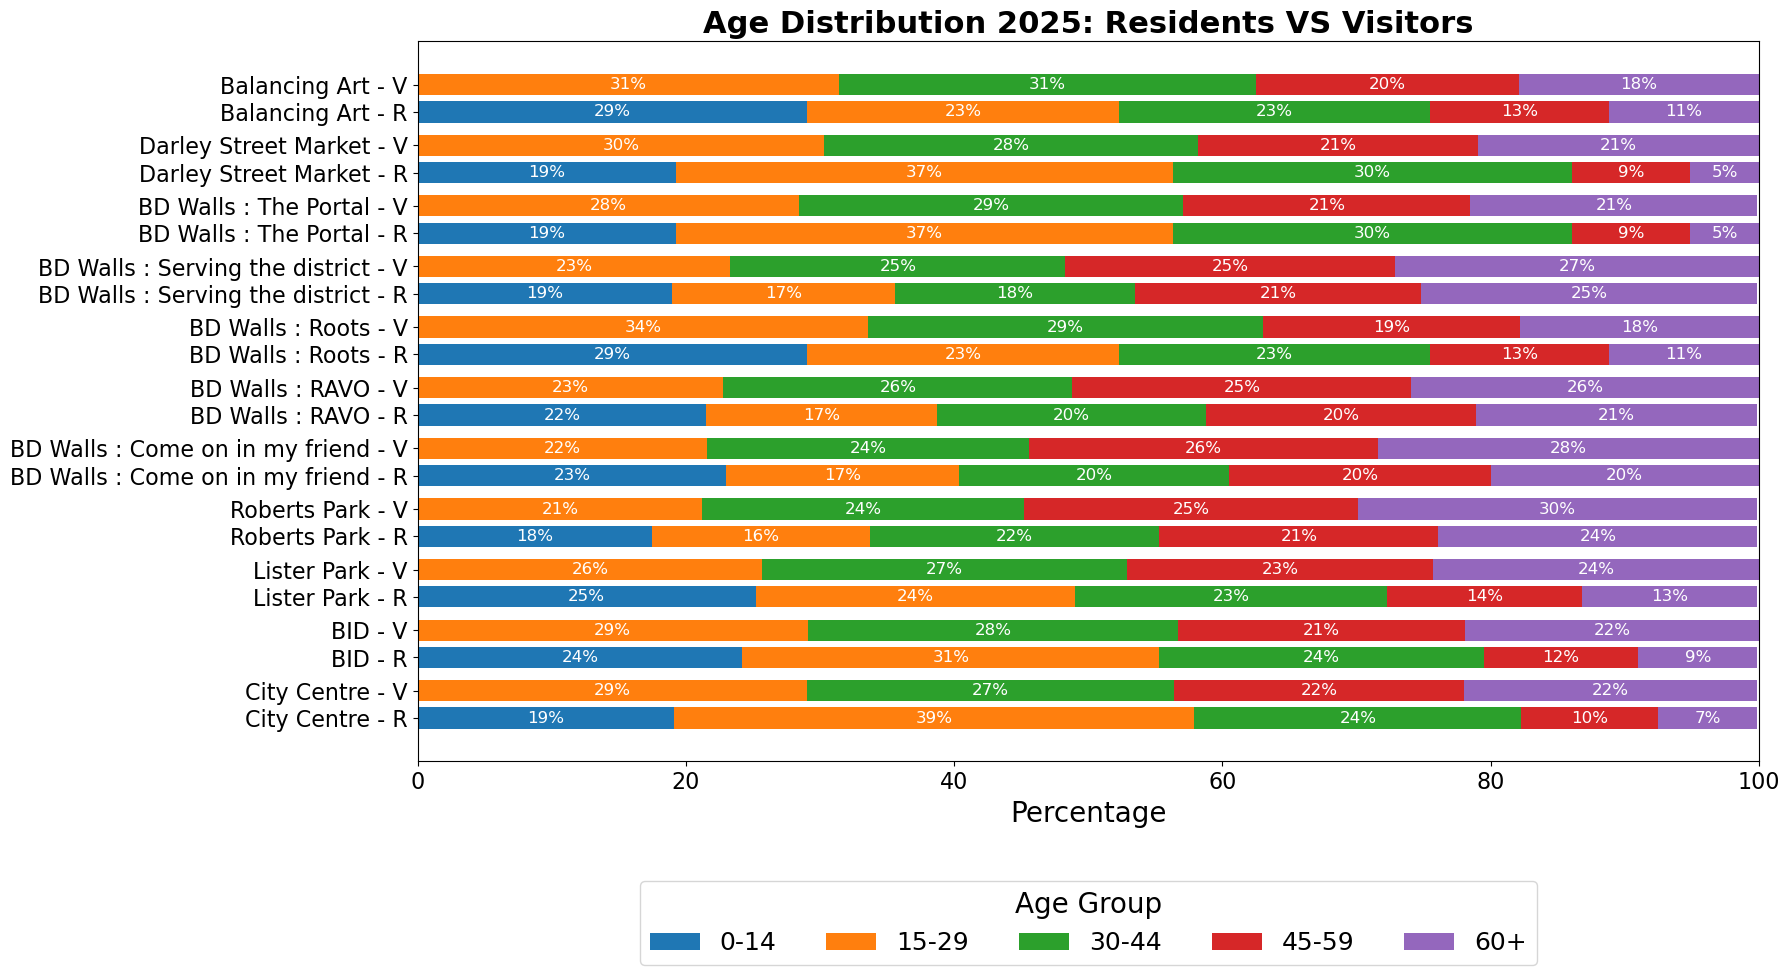

In [592]:
#Plot a Stacked Bar Chart
from matplotlib.patches import Patch


n_areas = len(pivot)
y = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(18, 10))

#Use same color palette for both
colors = plt.cm.tab10.colors
age_cols_res = age_res.columns
age_cols_vis = age_vis.columns

offset = ( 0.35 + 0.1) /2

#Plot Residents (with labels)
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_res):
    values = age_res[col].values
    bars = ax.barh(y - offset, 
                   values, 
                   left=left, 
                   height= 0.35, 
                   label=col, 
                   color=colors[i])
    #Add percenatge labels
    for j, v in enumerate(values):
        if v > 2: #hide small percentages
            ax.text(left[j] + v/2,
                    y[j] - offset,
                    f'{v:.0f}%',
                    ha= 'center',
                    va='center',
                    fontsize=12,
                    color= 'white')
    left += values

#Plot Visitors (no labels)
left = np.zeros(n_areas)
for i, col in enumerate(age_cols_vis):
    values = age_vis[col].values
    bars = ax.barh(y + offset, 
                   values, 
                   left=left, 
                   height= 0.35, 
                   label= '_nolegend_', 
                   color=colors[i])
    #Add percenatge labels
    for j, v in enumerate(values):
        if v > 2: #hide small percentages
            ax.text(left[j] + v/2,
                    y[j] + offset,
                    f'{v:.0f}%',
                    ha= 'center',
                    va='center',
                    fontsize=12,
                    color= 'white')
    left += values

#Create separate y ticks for each bar
y_ticks = np.concatenate([y - offset, y + offset])
y_labels = []
for area in pivot.index:
    y_labels.append(f'{area} - R')
for area in pivot.index:
    y_labels.append(f'{area} - V')

ax.set_yticks(y_ticks)
ax.set_yticklabels(y_labels, fontsize= 16)

ax.tick_params(axis='x', labelsize= 16)
ax.set_xlabel('Percentage', fontsize= 20)
ax.set_title('Age Distribution 2025: Residents VS Visitors', fontsize= 22, weight= 'bold')
ax.set_xlim(0, 100)

#Age group legend
ax.legend(title='Age Group', 
          title_fontsize= 20, 
          bbox_to_anchor=(0.5, -0.3), 
          loc='lower center', 
          fontsize=18, 
          ncol=len(age_cols_res))



plt.tight_layout()
plt.show()

### B) Investigate Gender

In [593]:
#Look into gender differences:
gender_res = pivot['Gender (Residents)']
gender_vis = pivot['Gender (Visitors)']

gender_vis

Group,Female,Male
area,,
City Centre,50.4,49.6
BID,50.1,49.9
Lister Park,50.4,49.6
Roberts Park,50.7,49.3
BD Walls : Come on in my friend,51.9,48.1
BD Walls : RAVO,51.5,48.5
BD Walls : Roots,49.8,50.2
BD Walls : Serving the district,50.9,49.1
BD Walls : The Portal,49.9,50.1


In [594]:
gender_res

Group,F,M
area,,
City Centre,46.2,53.8
BID,47.3,52.7
Lister Park,48.6,51.4
Roberts Park,49.7,50.3
BD Walls : Come on in my friend,52.3,47.7
BD Walls : RAVO,51.7,48.3
BD Walls : Roots,49.0,51.0
BD Walls : Serving the district,51.3,48.7
BD Walls : The Portal,44.8,55.2


In [595]:
#Gender Difference
gender_diff_res = abs(pivot['Gender (Residents)']['F'] - pivot['Gender (Residents)']['M'])
gender_diff_vis = abs(pivot['Gender (Visitors)']['Female'] - pivot['Gender (Visitors)']['Male'])

In [596]:
gender_diff_res

area
City Centre                         7.6
BID                                 5.4
Lister Park                         2.8
Roberts Park                        0.6
BD Walls : Come on in my friend     4.6
BD Walls : RAVO                     3.4
BD Walls : Roots                    2.0
BD Walls : Serving the district     2.6
BD Walls : The Portal              10.4
Darley Street Market               10.4
Balancing Art                       2.0
dtype: float64

In [597]:
gender_diff_vis

area
City Centre                        0.8
BID                                0.2
Lister Park                        0.8
Roberts Park                       1.4
BD Walls : Come on in my friend    3.8
BD Walls : RAVO                    3.0
BD Walls : Roots                   0.4
BD Walls : Serving the district    1.8
BD Walls : The Portal              0.2
Darley Street Market               0.0
Balancing Art                      0.2
dtype: float64

### C) Investigate Residents Household and Population

In [598]:
print(pivot['Population (Residents)']['Average Household Size'])
print((pivot['Population (Residents)']['Average Household Size']).mean())

area
City Centre                        2.49
BID                                2.77
Lister Park                        3.35
Roberts Park                       2.27
BD Walls : Come on in my friend    2.45
BD Walls : RAVO                    2.35
BD Walls : Roots                   2.93
BD Walls : Serving the district    2.36
BD Walls : The Portal              2.01
Darley Street Market               2.01
Balancing Art                      2.93
Name: Average Household Size, dtype: float64
2.5381818181818177


In [599]:
print(pivot['Population (Residents)']['Households'])
print((pivot['Population (Residents)']['Households']).mean())
print((pivot['Population (Residents)']['Households']).max())

area
City Centre                        2593.0
BID                                6369.0
Lister Park                        3583.0
Roberts Park                       1825.0
BD Walls : Come on in my friend    2869.0
BD Walls : RAVO                     858.0
BD Walls : Roots                   4343.0
BD Walls : Serving the district    3099.0
BD Walls : The Portal              1052.0
Darley Street Market               1052.0
Balancing Art                      4343.0
Name: Households, dtype: float64
2907.818181818182
6369.0


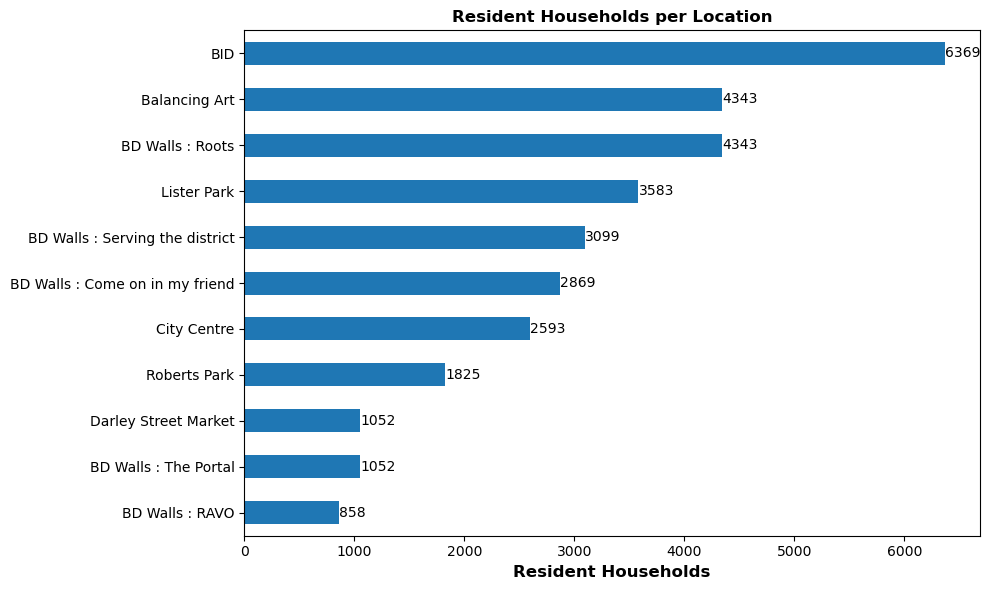

In [600]:
House = (pivot['Population (Residents)']['Households']).sort_values()

ax = House.plot(kind = 'barh', figsize=(10,6))
plt.xlabel('Resident Households', fontsize= 12, weight='bold')
plt.ylabel('')
plt.title('Resident Households per Location', weight= 'bold')

#Add values at end of bar
for i, v in enumerate(House):
    ax.text(v + 0.5, i , f'{v:.0f}', va='center')

plt.tight_layout()
plt.show()

In [601]:
print(pivot['Population (Residents)']['Total Population'])
print((pivot['Population (Residents)']['Total Population']).mean())
print((pivot['Population (Residents)']['Total Population']).max())

area
City Centre                         6467.0
BID                                17666.0
Lister Park                        12001.0
Roberts Park                        4140.0
BD Walls : Come on in my friend     7040.0
BD Walls : RAVO                     2020.0
BD Walls : Roots                   12720.0
BD Walls : Serving the district     7310.0
BD Walls : The Portal               2119.0
Darley Street Market                2119.0
Balancing Art                      12720.0
Name: Total Population, dtype: float64
7847.454545454545
17666.0


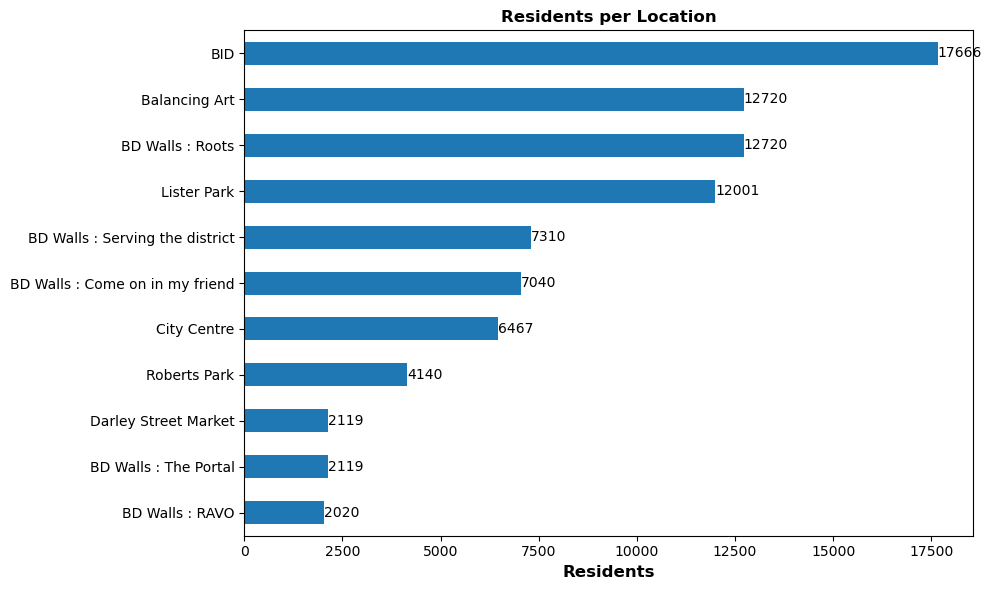

In [602]:
Res = (pivot['Population (Residents)']['Total Population']).sort_values()

ax = Res.plot(kind = 'barh', figsize=(10,6))
plt.xlabel('Residents', fontsize= 12, weight='bold')
plt.ylabel('')
plt.title('Residents per Location', weight= 'bold')

#Add values at end of bar
for i, v in enumerate(Res):
    ax.text(v + 0.5, i , f'{v:.0f}', va='center')

plt.tight_layout()
plt.show()

### D) Investigate Purchasing Power

In [603]:
print(pivot['Purchasing Power (Residents)']['EUR per capita'])
print((pivot['Purchasing Power (Residents)']['EUR per capita']).mean())
print((pivot['Purchasing Power (Residents)']['EUR per capita']).max())
print((pivot['Purchasing Power (Residents)']['EUR per capita']).min())

area
City Centre                        17049.44
BID                                13972.29
Lister Park                        14075.33
Roberts Park                       27425.85
BD Walls : Come on in my friend    17689.97
BD Walls : RAVO                    20281.94
BD Walls : Roots                   11998.92
BD Walls : Serving the district    20253.47
BD Walls : The Portal              21323.23
Darley Street Market               21323.23
Balancing Art                      11998.92
Name: EUR per capita, dtype: float64
17944.780909090914
27425.85
11998.92


In [604]:
print(pivot['Purchasing Power (Visitors)']['EUR per capita'])
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).mean())
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).max())
print((pivot['Purchasing Power (Visitors)']['EUR per capita']).min())

area
City Centre                        17065.64
BID                                17725.00
Lister Park                        18442.00
Roberts Park                       22077.77
BD Walls : Come on in my friend    17993.51
BD Walls : RAVO                    18717.26
BD Walls : Roots                   13764.85
BD Walls : Serving the district    19861.58
BD Walls : The Portal              17511.82
Darley Street Market               16298.91
Balancing Art                      13391.48
Name: EUR per capita, dtype: float64
17531.80181818182
22077.77
13391.48


In [605]:
#Difference between residents VS visitors purchasing power
PP_diff = abs(pivot['Purchasing Power (Residents)'] - pivot['Purchasing Power (Visitors)'])
PP_diff

Group,EUR per capita
area,
City Centre,16.20
BID,3752.71
Lister Park,4366.67
Roberts Park,5348.08
BD Walls : Come on in my friend,303.54
BD Walls : RAVO,1564.68
BD Walls : Roots,1765.93
BD Walls : Serving the district,391.89
BD Walls : The Portal,3811.41


In [606]:
print((PP_diff).mean())
print((PP_diff).max())

Group
EUR per capita    2521.635455
dtype: float64
Group
EUR per capita    5348.08
dtype: float64


In [607]:
( ((PP_diff).mean()) * 100 ) / ((pivot['Purchasing Power (Residents)']['EUR per capita']).mean())

Group
EUR per capita    14.052194
dtype: float64

In [608]:
PP = pivot[['Purchasing Power (Residents)', 'Purchasing Power (Visitors)']]
PP

Category,Purchasing Power (Residents),Purchasing Power (Visitors)
Group,EUR per capita,EUR per capita
area,,
City Centre,17049.44,17065.64
BID,13972.29,17725.00
Lister Park,14075.33,18442.00
Roberts Park,27425.85,22077.77
BD Walls : Come on in my friend,17689.97,17993.51
BD Walls : RAVO,20281.94,18717.26
BD Walls : Roots,11998.92,13764.85
BD Walls : Serving the district,20253.47,19861.58


In [609]:
PP.columns = [' '.join(col).strip() if isinstance(col, tuple) else col for col in PP.columns]
PP

,Purchasing Power (Residents) EUR per capita,Purchasing Power (Visitors) EUR per capita
area,,
City Centre,17049.44,17065.64
BID,13972.29,17725.00
Lister Park,14075.33,18442.00
Roberts Park,27425.85,22077.77
BD Walls : Come on in my friend,17689.97,17993.51
BD Walls : RAVO,20281.94,18717.26
BD Walls : Roots,11998.92,13764.85
BD Walls : Serving the district,20253.47,19861.58
BD Walls : The Portal,21323.23,17511.82


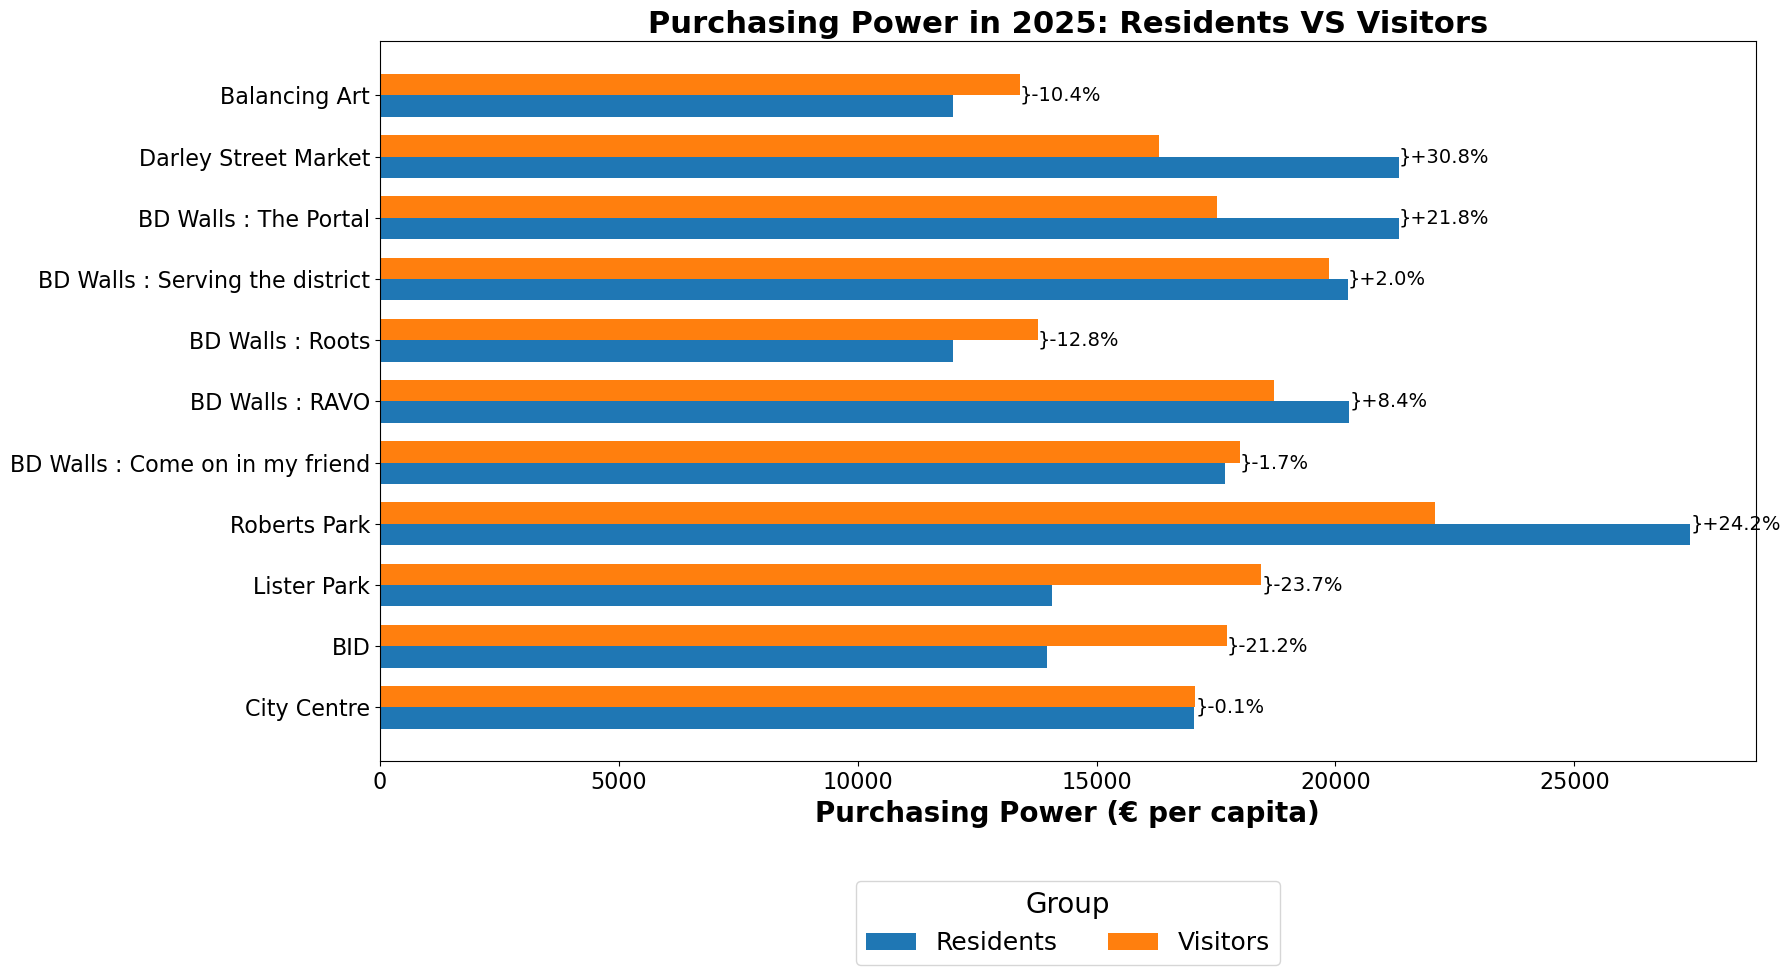

In [610]:
#Plot a Bar Chart of Purchasing Power

n_areas = len(pivot)
y = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(18, 10))

bar_height = 0.35
offset = bar_height/2

#Plot Residents (upper bar)
ax.barh(y - offset, 
        PP['Purchasing Power (Residents) EUR per capita'],  
        height= bar_height,
        label= 'Residents')

#Plot Visitors (lower)
ax.barh(y + offset, 
        PP['Purchasing Power (Visitors) EUR per capita'], 
        height= bar_height,
        label= 'Visitors')

ax.set_yticks(y)
ax.set_yticklabels(pivot.index, fontsize= 16)
ax.tick_params(axis='x', labelsize= 16)

ax.set_xlabel('Purchasing Power (€ per capita)', fontsize= 20, weight='bold')
ax.set_title('Purchasing Power in 2025: Residents VS Visitors', fontsize= 22, weight= 'bold')

# Group legend
ax.legend(title='Group', 
          title_fontsize= 20, 
          bbox_to_anchor=(0.5, -0.3), 
          loc='lower center', 
          fontsize=18, 
          ncol=len(age_cols_res))

for i in range(len(PP)):
        #calculate percentage difference
        if PP['Purchasing Power (Residents) EUR per capita'].iloc[i] != 0:
                diff_pct = ((PP['Purchasing Power (Residents) EUR per capita'].iloc[i] - PP['Purchasing Power (Visitors) EUR per capita'].iloc[i]) / PP['Purchasing Power (Visitors) EUR per capita'].iloc[i])* 100
        else:
                diff_pct = 0
        y_pos= i #position pct in middle of 2 bars

        ax.text(
                x= max(PP['Purchasing Power (Residents) EUR per capita'].iloc[i], PP['Purchasing Power (Visitors) EUR per capita'].iloc[i]) + 5, #small offset to the right
                y= y_pos,
                s= f"}}{diff_pct:+1.1f}%",
                va='center',
                fontsize= 14
        )
        
plt.tight_layout()
plt.show()

Note: Unsure how to investigate purchasing power buckets for visitors (have no residents comparison)

In [611]:
pivot_2025 = pivot

## Statistical Summary on Demographics

### A) Age

* Across the 13 areas, residents aged 19-29 represented the largest age group, accounting for 23.9% overall, and ranging from 13.5% to 40.3%. This was particularly pronounced in the 'Bradford City Centre' (40.3%), 'BD Walls - The Portal' (37%) and 'Draley Street Market' (37%).
* By contrast, the 45-59 and 60+ age groups constituted the smallest shares of residents across areas, each representing around 16%.
* In contrast to the resident profile, visitors across the 13 areas were predominantly aged 30-44, comprising 26.3% of visitors overall, ranging from 22.7% to 29.6%. This pattern was most evident in the 'BD Walls - The Portal' (29.5%), 'BD Walls Roots' (29.6%) areas.
* Visitors aged 45-59 formed the smallest visitor group, accounting for 23.49% of visitors.
* Visitors in 'Draley Street Market' area were 16.3% more likely to be aged over 60 than residents.

### B) Gender

* Resident gender distribution was broadly balanced across most areas. However, in the 'BD Walls - The Portal' and 'Draley Street Market' areas, the share of female residents were around 10% lower than male residents, indicating a notable gender imbalance.
* Visitors gender distribution were evenly distributed in all areas, showing no significant variation by location.

### C) Households and Population

* Across the 13 aresa, the average household size was 2.5.
* The Bradford BID area had the highest concentration of households, with a total of 6369 households.
* On average, areas had 7566 residents, with Bradford BID recodring the largest population of 17666 residents.


### D) Purchasing Power

* Across the areas, residents had an average of 19591 euros per capita purchasing power. 'Baildon' area had the highest purchasing power with 28024.93 euros per capita, and 'Coates Street, Bradford Foyer, Coates TER, Wootton Street' in contrast was the area with the lowest purchasing power of 11998.92 euros per capita.
* Across the areas, visitors had an average of 19055.99 euros per capita purchasing power. 'BD WALL - Wayfinders' area had the highest purchasing power with 25135.73 euros per capita, and 'BD Walls Roots' in contrast was the area with the lowest purchasing power of 15047.41 euros per capita.
* On average, residents' purchasing power was 15% higher than visitors'. The 'Draley Street Market' area for example had a 4288.01 euros per capita difference between its residents and visitors.
*

## Combining the demographics, dwell, footfall and sales data of the 13 areas provided - for 2024

In [612]:
import glob
import os

#Folder with containing all areas
folder_path = r"C:\Users\qxnq723\Desktop\Project 1\HUQ Data\Data 2024"

#Find all CSVs in all subfolders
area_folders = glob.glob(os.path.join(folder_path, '*'))

#Define file names
custom_names = ['demographics', 'dwell', 'footfall']

#Dict to store combined dataframes by file type
combined = {name: pd.DataFrame() for name in custom_names}

for area_path in area_folders:
    #Get area name
    area_name = os.path.basename(area_path)
    
    csv_files = sorted(glob.glob(os.path.join(area_path, '*.csv')))
    
    #Loop over CSVs and assign new name
    for i, file in enumerate (csv_files):
        df = pd.read_csv(file, encoding='cp1252')
        
        #Add area column
        df['region'] = area_name
        
        #Get the new names
        new_name = custom_names[i]
        
        #Concatenate into 
        combined[new_name] = pd.concat([combined[new_name], df], ignore_index=True)

#Check
print(combined['demographics'].head())

    ï»¿area         Category  Group  Value         region
0  Bradford  Age (Residents)   0-14  29.0%  Balancing Art
1  Bradford  Age (Residents)  15-29  23.3%  Balancing Art
2  Bradford  Age (Residents)  30-44  23.2%  Balancing Art
3  Bradford  Age (Residents)  45-59  13.3%  Balancing Art
4  Bradford  Age (Residents)    60+  11.2%  Balancing Art


In [613]:
print(combined['demographics']['region'].unique())

['Balancing Art' 'BD Walls - Come on in my friend' 'BD Walls - RAVO'
 'BD Walls - Roots' 'BD Walls - Serving the district'
 'BD Walls - The Portal' 'BID' 'City centre' 'Darley Street Market'
 'Lister Park' 'Roberts Park']


In [614]:
combined.keys()

dict_keys(['demographics', 'dwell', 'footfall'])

In [615]:
#Extract into separate dataframes
df_demo_2024 = combined['demographics']
df_dwell_2024 = combined['dwell']
df_footfall_2024 = combined['footfall']

In [616]:
#Take out the % for calculations
df_demo_2024['Value'] = df_demo_2024['Value'].str.replace('%', '', regex=True)
#Convert Value column to numerical instead of object
df_demo_2024['Value'] = pd.to_numeric(df_demo_2024['Value'], errors='coerce')
df_demo_2024.head()

,ï»¿area,Category,Group,Value,region
0,Bradford,Age (Residents),0-14,29.0,Balancing Art
1,Bradford,Age (Residents),15-29,23.3,Balancing Art
2,Bradford,Age (Residents),30-44,23.2,Balancing Art
3,Bradford,Age (Residents),45-59,13.3,Balancing Art
4,Bradford,Age (Residents),60+,11.2,Balancing Art


In [617]:
#Rename some of the area names
df_demo_2024 = df_demo_2024.drop(columns=['ï»¿area'])
df_demo_2024 = df_demo_2024.rename(columns={'region': 'area'})

df_demo_2024['area'] = df_demo_2024['area'].replace('BD Walls - Come on in my friend', 'BD Walls : Come on in my friend')
df_demo_2024['area'] = df_demo_2024['area'].replace('BD Walls - RAVO', 'BD Walls : RAVO')
df_demo_2024['area'] = df_demo_2024['area'].replace('BD Walls - Roots', 'BD Walls : Roots')
df_demo_2024['area'] = df_demo_2024['area'].replace('BD Walls - Serving the district', 'BD Walls : Serving the district')
df_demo_2024['area'] = df_demo_2024['area'].replace('BD Walls - The Portal', 'BD Walls : The Portal')
df_demo_2024['area'] = df_demo_2024['area'].replace('City centre', 'City Centre')

In [618]:
#Create pivot table for better readability
pivot_2024 = df_demo_2024.pivot_table(index= 'area', 
                            columns= ['Category', 'Group'], 
                            values='Value',
                            aggfunc= 'mean')

pivot_2024

Category                        Age (Residents)                          \
Group                                      0-14 15-29 30-44 45-59   60+   
area                                                                      
BD Walls : Come on in my friend            23.2  17.5  20.2  19.4  19.7   
BD Walls : RAVO                            21.0  17.0  20.3  20.0  21.5   
BD Walls : Roots                           29.0  23.3  23.2  13.3  11.2   
BD Walls : Serving the district            19.0  16.6  17.9  21.3  25.1   
BD Walls : The Portal                      19.3  37.0  29.8   8.8   5.1   
BID                                        24.2  31.1  24.2  11.5   8.9   
Balancing Art                              29.0  23.3  23.2  13.3  11.2   
City Centre                                19.1  38.8  24.4  10.2   7.4   
Darley Street Market                       19.3  37.0  29.8   8.8   5.1   
Lister Park                                25.2  23.8  23.3  14.5  13.1   
Roberts Park                               17.2  15.3  21.4  21.0  25.0   

Category                        Age (Visitors)                    \
Group                                    15-29 30-44 45-59   60+   
area                                                               
BD Walls : Come on in my friend           21.5  23.4  26.0  29.0   
BD Walls : RAVO                           23.3  25.7  24.5  26.4   
BD Walls : Roots                          28.1  29.3  21.4  21.0   
BD Walls : Serving the district           22.9  24.7  25.0  27.5   
BD Walls : The Portal                     26.6  28.8  22.3  22.3   
BID                                       27.4  27.3  22.2  23.1   
Balancing Art                             26.5  27.0  22.7  23.8   
City Centre                               27.3  27.1  22.3  23.2   
Darley Street Market                      26.3  27.6  22.6  23.3   
Lister Park                               26.4  27.7  22.4  23.3   
Roberts Park                              18.7  23.2  26.4  31.7   

Category                        Gender (Residents)  ...  \
Group                                            F  ...   
area                                                ...   
BD Walls : Come on in my friend               52.3  ...   
BD Walls : RAVO                               51.8  ...   
BD Walls : Roots                              49.0  ...   
BD Walls : Serving the district               51.3  ...   
BD Walls : The Portal                         44.8  ...   
BID                                           47.3  ...   
Balancing Art                                 49.0  ...   
City Centre                                   46.2  ...   
Darley Street Market                          44.8  ...   
Lister Park                                   48.6  ...   
Roberts Park                                  50.4  ...   

Category                        Purchasing Power Buckets (Visitors)  \
Group                                                  Bucket 24500   
area                                                                  
BD Walls : Come on in my friend                                 3.0   
BD Walls : RAVO                                                34.0   
BD Walls : Roots                                                4.0   
BD Walls : Serving the district                                13.0   
BD Walls : The Portal                                           5.0   
BID                                                             9.0   
Balancing Art                                                   6.0   
City Centre                                                    11.0   
Darley Street Market                                           18.0   
Lister Park                                                    14.0   
Roberts Park                                                   63.0   

Category                                                               \
Group                           Bucket 28000 Bucket 31500 Bucket 3500   
area                        

In [619]:
df_demo_2024['area'].unique()

array(['Balancing Art', 'BD Walls : Come on in my friend',
       'BD Walls : RAVO', 'BD Walls : Roots',
       'BD Walls : Serving the district', 'BD Walls : The Portal', 'BID',
       'City Centre', 'Darley Street Market', 'Lister Park',
       'Roberts Park'], dtype=object)

In [620]:
#Change the order of the areas indexed
new_order = ['City Centre',
             'BID',
             'Lister Park', 
             'Roberts Park',
             'BD Walls : Come on in my friend',
             'BD Walls : RAVO', 
             'BD Walls : Roots',
             'BD Walls : Serving the district', 
             'BD Walls : The Portal',
             'Darley Street Market',
             'Balancing Art']


pivot_2024 = pivot_2024.loc[new_order]

In [621]:
pivot_2024.describe()

Category Age (Residents)                                              \
Group               0-14      15-29      30-44      45-59        60+   
count          11.000000  11.000000  11.000000  11.000000  11.000000   
mean           22.318182  25.518182  23.427273  14.736364  13.936364   
std             4.116265   8.971156   3.711358   4.873248   7.598588   
min            17.200000  15.300000  17.900000   8.800000   5.100000   
25%            19.200000  17.250000  20.850000  10.850000   8.150000   
50%            21.000000  23.300000  23.200000  13.300000  11.200000   
75%            24.700000  34.050000  24.300000  19.700000  20.600000   
max            29.000000  38.800000  29.800000  21.300000  25.100000   

Category Age (Visitors)                                  Gender (Residents)  \
Group             15-29      30-44      45-59        60+                  F   
count         11.000000  11.000000  11.000000  11.000000          11.000000   
mean          25.000000  26.527273  23.436364  24.963636          48.681818   
std            2.972541   2.034744   1.717715   3.262598           2.665265   
min           18.700000  23.200000  21.400000  21.000000          44.800000   
25%           23.100000  25.200000  22.300000  23.150000          46.750000   
50%           26.400000  27.100000  22.600000  23.300000          49.000000   
75%           26.950000  27.650000  24.750000  26.950000          50.850000   
max           28.100000  29.300000  26.400000  31.700000          52.300000   

Category  ... Purchasing Power Buckets (Visitors)                            \
Group     ...                        Bucket 24500 Bucket 28000 Bucket 31500   
count     ...                           11.000000    10.000000     6.000000   
mean      ...                           16.363636     2.800000     0.333333   
std       ...                           17.766670     2.440401     0.516398   
min       ...                            3.000000     0.000000     0.000000   
25%       ...                            5.500000     2.000000     0.000000   
50%       ...                           11.000000     2.000000     0.000000   
75%       ...                           16.000000     3.000000     0.750000   
max       ...                           63.000000     9.000000     1.000000   

Category                                                                  \
Group    Bucket 3500 Bucket 35000 Bucket 38500 Bucket 42000 Bucket 45500   
count           4.00     6.000000          1.0     6.000000          1.0   
mean            0.25     0.333333          0.0     0.166667          1.0   
std             0.50     0.516398          NaN     0.408248          NaN   
min             0.00     0.000000          0.0     0.000000          1.0   
25%             0.00     0.000000          0.0     0.000000          1.0   
50%             0.00     0.000000          0.0     0.000000          1.0   
75%             0.25     0.750000          0.0     0.000000          1.0   
max             1.00     1.000000          0.0     1.000000          1.0   

Category                           
Group    Bucket 63000 Bucket 7000  
count             4.0   11.000000  
mean              0.0    2.909091  
std               0.0    1.700267  
min               0.0    1.000000  
25%               0.0    1.500000  
50%               0.0    3.000000  
75%               0.0    4.000000  
max               0.0    6.000000  

[8 rows x 32 columns]

In [622]:
pivot_2024.info()

<class 'pandas.core.frame.DataFrame'>
Index: 11 entries, City Centre to Balancing Art
Data columns (total 32 columns):
 #   Column                                               Non-Null Count  Dtype  
---  ------                                               --------------  -----  
 0   (Age (Residents), 0-14)                              11 non-null     float64
 1   (Age (Residents), 15-29)                             11 non-null     float64
 2   (Age (Residents), 30-44)                             11 non-null     float64
 3   (Age (Residents), 45-59)                             11 non-null     float64
 4   (Age (Residents), 60+)                               11 non-null     float64
 5   (Age (Visitors), 15-29)                              11 non-null     float64
 6   (Age (Visitors), 30-44)                              11 non-null     float64
 7   (Age (Visitors), 45-59)                              11 non-null     float64
 8   (Age (Visitors), 60+)                                11 

Combine the initial 2024 and 2025 demographics data (not in pivot format) and export as excel file to then be used in Tableau to build a dashboard:

In [623]:
df_demo_2024['Year'] = 2024
df_demo_2025['Year'] = 2025

#Concatenate 2024 with 2025
Demo_combined = pd.concat([df_demo_2024, df_demo_2025])

Demo_combined

,Category,Group,Value,area,Year
0,Age (Residents),0-14,29.0,Balancing Art,2024
1,Age (Residents),15-29,23.3,Balancing Art,2024
2,Age (Residents),30-44,23.2,Balancing Art,2024
3,Age (Residents),45-59,13.3,Balancing Art,2024
4,Age (Residents),60+,11.2,Balancing Art,2024
...,...,...,...,...,...
281,Purchasing Power Buckets (Visitors),Bucket 17500,24.0,Roberts Park,2025
282,Purchasing Power Buckets (Visitors),Bucket 21000,4.0,Roberts Park,2025
283,Purchasing Power Buckets (Visitors),Bucket 24500,42.0,Roberts Park,2025
284,Purchasing Power Buckets (Visitors),Bucket 28000,5.0,Roberts Park,2025


In [624]:
Demo_combined['Group'] = Demo_combined['Group'].replace({'M': 'Male', 'F':'Female'})
Demo_combined

,Category,Group,Value,area,Year
0,Age (Residents),0-14,29.0,Balancing Art,2024
1,Age (Residents),15-29,23.3,Balancing Art,2024
2,Age (Residents),30-44,23.2,Balancing Art,2024
3,Age (Residents),45-59,13.3,Balancing Art,2024
4,Age (Residents),60+,11.2,Balancing Art,2024
...,...,...,...,...,...
281,Purchasing Power Buckets (Visitors),Bucket 17500,24.0,Roberts Park,2025
282,Purchasing Power Buckets (Visitors),Bucket 21000,4.0,Roberts Park,2025
283,Purchasing Power Buckets (Visitors),Bucket 24500,42.0,Roberts Park,2025
284,Purchasing Power Buckets (Visitors),Bucket 28000,5.0,Roberts Park,2025


In [625]:
Demo_combined[Demo_combined['Group']== 'Bucket 80500']['Value']

208    0.0
Name: Value, dtype: float64

In [626]:
pip install pandas openpyxl

Note: you may need to restart the kernel to use updated packages.


In [627]:
Demo_combined.to_excel('demographics_24-25.xlsx')

## II - Exploratory Data Analysis: Dwell

First look at dwell data in 2025:

In [628]:
df_dwell_2025['area'].unique()

array(['Bradford', 'BD walls : Come on in my friend BD5 3PX',
       'BD Walls RAVO', 'BD Walls : Root 1 Coates St, Bradford BD5 7DL',
       'BD walls: Serving the district Morrisons, Bradford Road, Idle BD10',
       'BD walls the portal BD1 CBH', 'Bradford city centre', nan,
       "Darley's street market", 'Lister Park',
       'Painting the sky - Roberts part'], dtype=object)

In [629]:
#Rename some of the area names
df_dwell_2025['area'] = df_dwell_2025['area'].fillna('BID')

df_dwell_2025['area'] = df_dwell_2025['area'].replace('Bradford', 'Balancing Art')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('BD walls : Come on in my friend BD5 3PX', 'BD Walls : Come on in my friend')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('BD Walls RAVO', 'BD Walls : RAVO')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('BD Walls : Root 1 Coates St, Bradford BD5 7DL', 'BD Walls : Roots')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('BD walls: Serving the district Morrisons, Bradford Road, Idle BD10', 'BD Walls : Serving the district')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('BD walls the portal BD1 CBH', 'BD Walls : The Portal')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('Bradford city centre', 'City Centre')
df_dwell_2025['area'] = df_dwell_2025['area'].replace("Darley's street market", 'Darley Street Market')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('Lister Park', 'Lister Park')
df_dwell_2025['area'] = df_dwell_2025['area'].replace('Painting the sky - Roberts part', 'Roberts Park')

In [630]:
#Keep only the rows with days of the week dwell time
days = {'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'}

#Keep only the daily intervals
df_dwell_2025 = df_dwell_2025[df_dwell_2025['Category'].isin(days)]
df_dwell_2025

,area,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),region,ï»¿area
7,Balancing Art,Dwell Time by Day of Week,Monday,0.0 minutes,0.0 minutes,0.0 minutes,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
8,Balancing Art,Dwell Time by Day of Week,Tuesday,0.0 minutes,0.0 minutes,0.0 minutes,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
9,Balancing Art,Dwell Time by Day of Week,Wednesday,0.0 minutes,0.0 minutes,0.0 minutes,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
10,Balancing Art,Dwell Time by Day of Week,Thursday,0.0 minutes,0.0 minutes,0.0 minutes,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
11,Balancing Art,Dwell Time by Day of Week,Friday,0.0 minutes,0.0 minutes,0.0 minutes,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
...,...,...,...,...,...,...,...,...
149,Roberts Park,Dwell Time by Day of Week,Wednesday,53.4 minutes,53.4 minutes,0.0 minutes,Painting the Sky - Roberts Park BD17 7LU,NaN
150,Roberts Park,Dwell Time by Day of Week,Thursday,64.4 minutes,64.4 minutes,0.0 minutes,Painting the Sky - Roberts Park BD17 7LU,NaN
151,Roberts Park,Dwell Time by Day of Week,Friday,36.7 minutes,36.7 minutes,0.0 minutes,Painting the Sky - Roberts Park BD17 7LU,NaN
152,Roberts Park,Dwell Time by Day of Week,Saturday,59.4 minutes,0.0 minutes,59.4 minutes,Painting the Sky - Roberts Park BD17 7LU,NaN


In [631]:
#Take out the minutes text for calculations
cols = ['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']
df_dwell_2025[cols] = df_dwell_2025[cols].replace(' minutes', '', regex=True)
#Convert columns to numerical instead of object
df_dwell_2025[cols] = df_dwell_2025[cols].apply(pd.to_numeric, errors='coerce')
df_dwell_2025.head()

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\728908105.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dwell_2025[cols] = df_dwell_2025[cols].replace(' minutes', '', regex=True)
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\728908105.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_dwell_2025[cols] = df_dwell_2025[cols].apply(pd.to_numeric, errors='coerce')


,area,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),region,ï»¿area
7,Balancing Art,Dwell Time by Day of Week,Monday,0.0,0.0,0.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
8,Balancing Art,Dwell Time by Day of Week,Tuesday,0.0,0.0,0.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
9,Balancing Art,Dwell Time by Day of Week,Wednesday,0.0,0.0,0.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
10,Balancing Art,Dwell Time by Day of Week,Thursday,0.0,0.0,0.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN
11,Balancing Art,Dwell Time by Day of Week,Friday,0.0,0.0,0.0,"Balancing Acts - 1 Coates Street, Bradford, BD...",NaN


In [632]:
#Create average across days of the week for all areas
df_av_2025 = df_dwell_2025.groupby('area')['Value (All days of week)'].mean().sort_values()
df_av_2025.head(20)

area
BD Walls : Serving the district     25.771429
Lister Park                         47.242857
Roberts Park                        63.371429
BD Walls : The Portal               82.700000
Balancing Art                       86.342857
BD Walls : Come on in my friend     87.200000
Darley Street Market                88.828571
BD Walls : Roots                    98.600000
City Centre                        180.657143
BID                                268.771429
BD Walls : RAVO                    571.171429
Name: Value (All days of week), dtype: float64

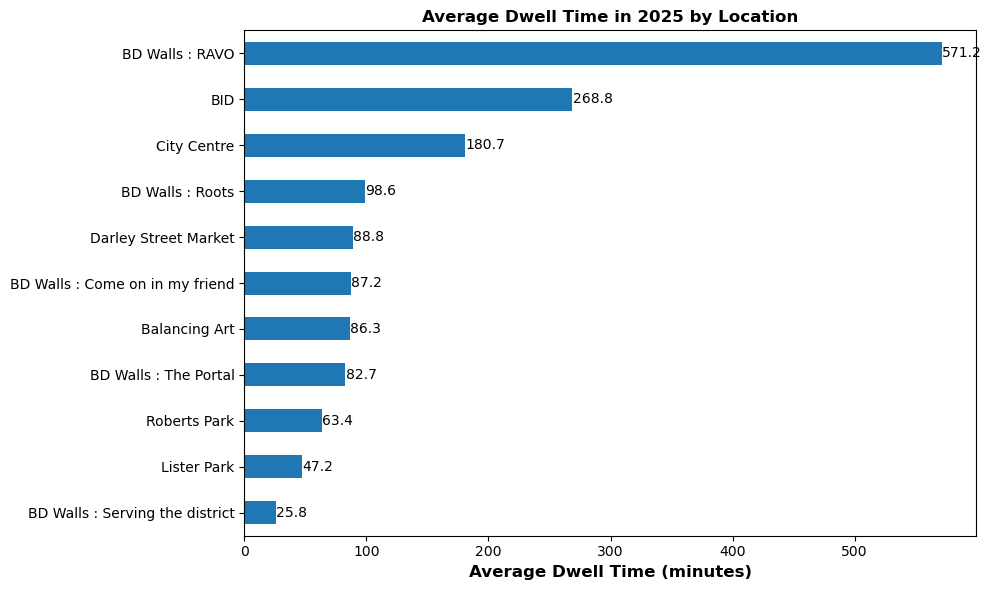

In [633]:
ax = df_av_2025.plot(kind = 'barh', figsize=(10,6))
plt.xlabel('Average Dwell Time (minutes)', fontsize= 12, weight='bold')
plt.ylabel('')
plt.title('Average Dwell Time in 2025 by Location', weight= 'bold')

#Add values at end of bar
for i, v in enumerate(df_av_2025):
    ax.text(v + 0.5, i , f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

Second, look at dwell data in 2024:

In [634]:
df_dwell_2024

,ï»¿area,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),region
0,Bradford,Dwell Time Distribution,0-30 min,10.6%,11.0%,10.0%,Balancing Art
1,Bradford,Dwell Time Distribution,30-2hrs,32.6%,19.6%,49.5%,Balancing Art
2,Bradford,Dwell Time Distribution,2-4 hrs,54.1%,69.4%,34.4%,Balancing Art
3,Bradford,Dwell Time Distribution,4-6 hrs,2.7%,0.0%,6.1%,Balancing Art
4,Bradford,Dwell Time Distribution,6-8 hrs,0.0%,0.0%,0.0%,Balancing Art
...,...,...,...,...,...,...,...
149,Baildon,Dwell Time by Day of Week,Wednesday,113.0 minutes,113.0 minutes,0.0 minutes,Roberts Park
150,Baildon,Dwell Time by Day of Week,Thursday,72.5 minutes,72.5 minutes,0.0 minutes,Roberts Park
151,Baildon,Dwell Time by Day of Week,Friday,55.5 minutes,55.5 minutes,0.0 minutes,Roberts Park
152,Baildon,Dwell Time by Day of Week,Saturday,42.4 minutes,0.0 minutes,42.4 minutes,Roberts Park


In [635]:
df_dwell_2024['region'].unique()

array(['Balancing Art', 'BD Walls - Come on in my friend',
       'BD Walls - RAVO', 'BD Walls - Roots',
       'BD Walls - Serving the district', 'BD Walls - The Portal', 'BID',
       'City centre', 'Darley Street Market', 'Lister Park',
       'Roberts Park'], dtype=object)

In [636]:
#Rename some of the area names
df_dwell_2024 = df_dwell_2024.drop(columns=['ï»¿area'])
df_dwell_2024 = df_dwell_2024.rename(columns={'region': 'area'})

df_dwell_2024['area'] = df_dwell_2024['area'].replace('BD Walls - Come on in my friend', 'BD Walls : Come on in my friend')
df_dwell_2024['area'] = df_dwell_2024['area'].replace('BD Walls - RAVO', 'BD Walls : RAVO')
df_dwell_2024['area'] = df_dwell_2024['area'].replace('BD Walls - Roots', 'BD Walls : Roots')
df_dwell_2024['area'] = df_dwell_2024['area'].replace('BD Walls - Serving the district', 'BD Walls : Serving the district')
df_dwell_2024['area'] = df_dwell_2024['area'].replace('BD Walls - The Portal', 'BD Walls : The Portal')
df_dwell_2024['area'] = df_dwell_2024['area'].replace('City centre', 'City Centre')

In [637]:
#Keep only the rows with days of the week dwell time
days = {'Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday'}

#Keep only the daily intervals
df_dwell_2024 = df_dwell_2024[df_dwell_2024['Category'].isin(days)]
df_dwell_2024

,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),area
7,Dwell Time by Day of Week,Monday,0.0 minutes,0.0 minutes,0.0 minutes,Balancing Art
8,Dwell Time by Day of Week,Tuesday,146.8 minutes,146.8 minutes,0.0 minutes,Balancing Art
9,Dwell Time by Day of Week,Wednesday,128.1 minutes,128.1 minutes,0.0 minutes,Balancing Art
10,Dwell Time by Day of Week,Thursday,0.0 minutes,0.0 minutes,0.0 minutes,Balancing Art
11,Dwell Time by Day of Week,Friday,16.7 minutes,16.7 minutes,0.0 minutes,Balancing Art
...,...,...,...,...,...,...
149,Dwell Time by Day of Week,Wednesday,113.0 minutes,113.0 minutes,0.0 minutes,Roberts Park
150,Dwell Time by Day of Week,Thursday,72.5 minutes,72.5 minutes,0.0 minutes,Roberts Park
151,Dwell Time by Day of Week,Friday,55.5 minutes,55.5 minutes,0.0 minutes,Roberts Park
152,Dwell Time by Day of Week,Saturday,42.4 minutes,0.0 minutes,42.4 minutes,Roberts Park


In [638]:
#Take out the minutes text for calculations
cols = ['Value (All days of week)', 'Value (Weekdays only)', 'Value (Weekends only)']
df_dwell_2024[cols] = df_dwell_2024[cols].replace(' minutes', '', regex=True)
#Convert columns to numerical instead of object
df_dwell_2024[cols] = df_dwell_2024[cols].apply(pd.to_numeric, errors='coerce')
df_dwell_2024.head()

,common.dataType,Category,Value (All days of week),Value (Weekdays only),Value (Weekends only),area
7,Dwell Time by Day of Week,Monday,0.0,0.0,0.0,Balancing Art
8,Dwell Time by Day of Week,Tuesday,146.8,146.8,0.0,Balancing Art
9,Dwell Time by Day of Week,Wednesday,128.1,128.1,0.0,Balancing Art
10,Dwell Time by Day of Week,Thursday,0.0,0.0,0.0,Balancing Art
11,Dwell Time by Day of Week,Friday,16.7,16.7,0.0,Balancing Art


In [639]:
#Create average across days of the week for all areas
df_av_2024 = df_dwell_2024.groupby('area')['Value (All days of week)'].mean().sort_values()
df_av_2024.head(20)

area
BD Walls : RAVO                      6.085714
BD Walls : Come on in my friend     17.157143
BD Walls : Serving the district     23.942857
BD Walls : The Portal               48.785714
Lister Park                         49.228571
BD Walls : Roots                    70.157143
Balancing Art                       74.385714
Roberts Park                        97.557143
City Centre                        171.100000
BID                                193.528571
Darley Street Market               428.471429
Name: Value (All days of week), dtype: float64

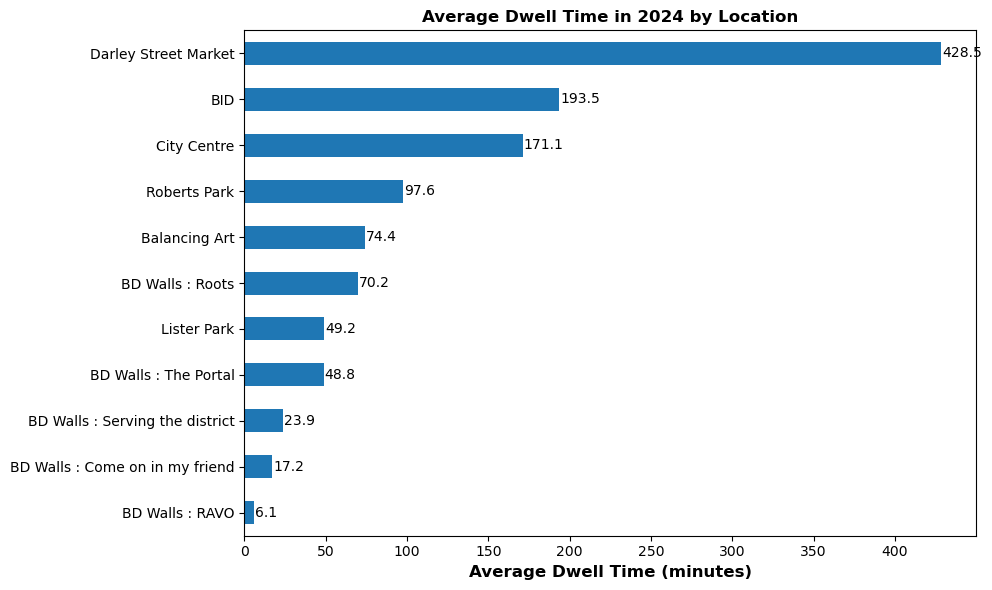

In [640]:
ax = df_av_2024.plot(kind = 'barh', figsize=(10,6))
plt.xlabel('Average Dwell Time (minutes)', fontsize= 12, weight='bold')
plt.ylabel('')
plt.title('Average Dwell Time in 2024 by Location', weight= 'bold')

#Add values at end of bar
for i, v in enumerate(df_av_2024):
    ax.text(v + 0.5, i , f'{v:.1f}', va='center')

plt.tight_layout()
plt.show()

Create plot comapring dwell time in 2024 vs 2025:

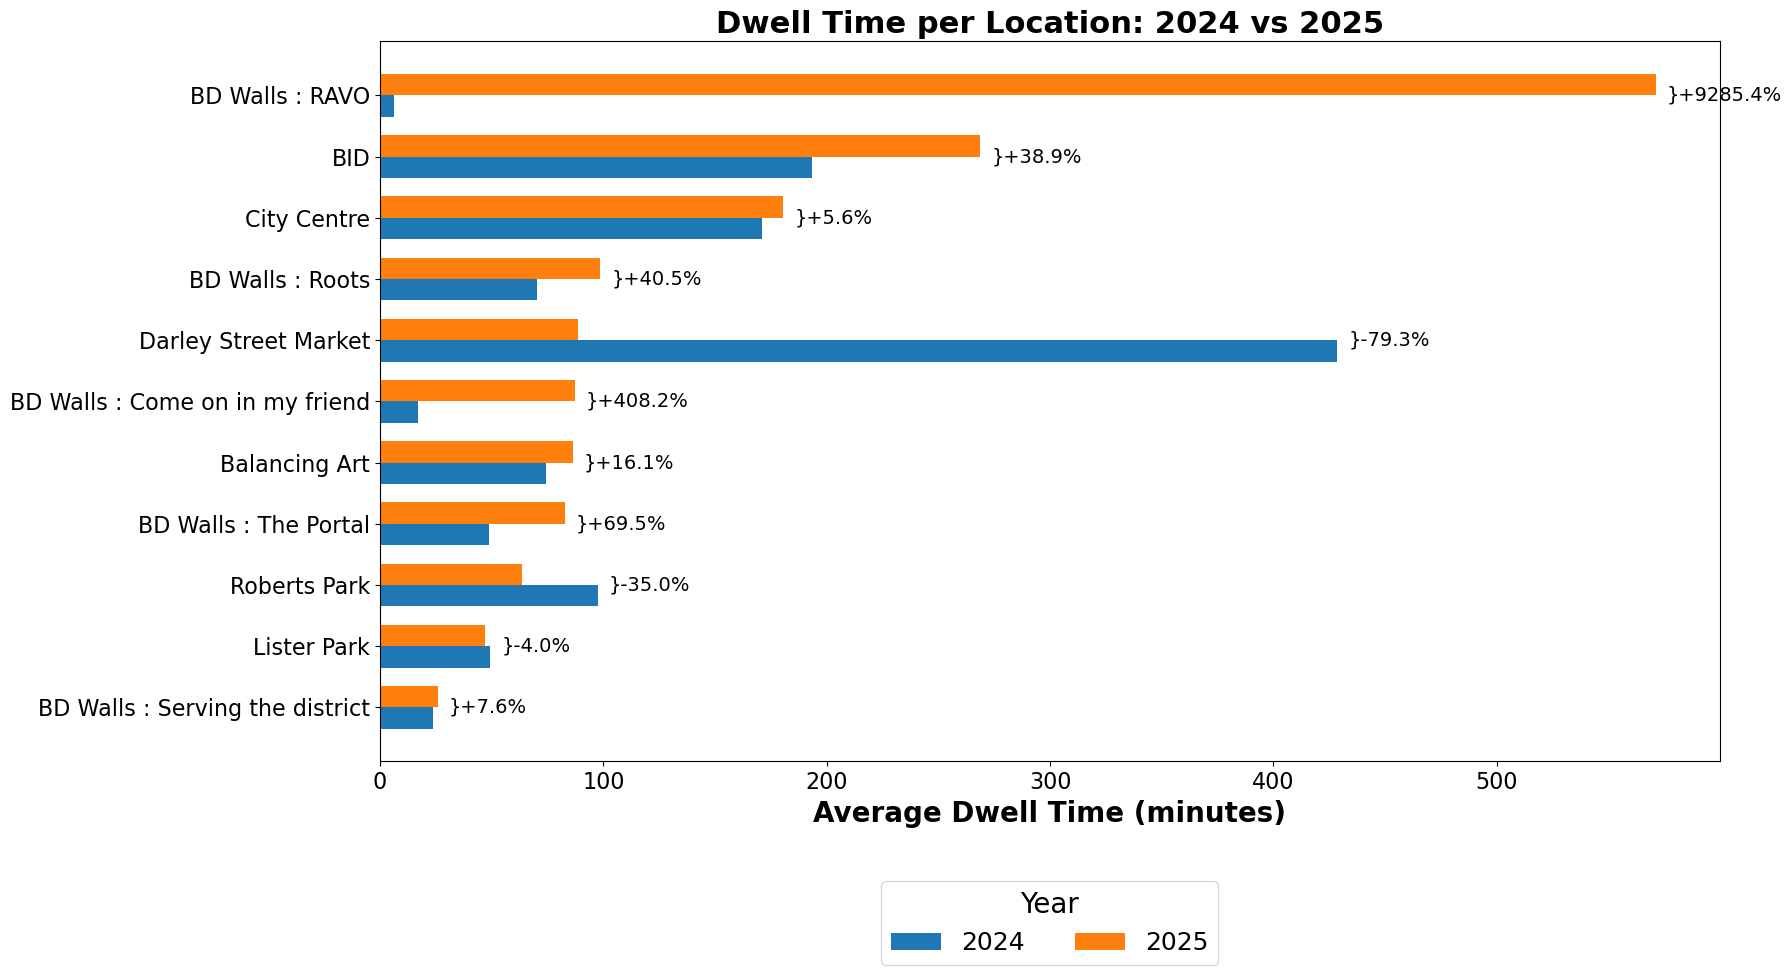

In [641]:
#Plot a Bar Chart of Dwell Time comparison

#Align both series for comparison (have diffrent area orders)

df_av_2025 = df_av_2025.reindex(df_av_2024.index)
#Sort by 2025 values (ascending)
order = df_av_2025.sort_values(ascending=True).index
df_av_2025 = df_av_2025.loc[order]
df_av_2024 = df_av_2024.loc[order]

n_areas = len(df_av_2024)
y = np.arange(n_areas)

fig, ax = plt.subplots(figsize=(18, 10))

bar_height = 0.35
offset = bar_height/2

#Plot Dwell 2024 (lower bar)
ax.barh(y - offset, 
        df_av_2024.values,  
        height= bar_height,
        label= '2024')

#Plot Dwell 2025 (upper bar)
ax.barh(y + offset, 
        df_av_2025.values, 
        height= bar_height,
        label= '2025')

ax.set_yticks(y)
ax.set_yticklabels(df_av_2024.index, fontsize= 16)
ax.tick_params(axis='x', labelsize= 16)

ax.set_xlabel('Average Dwell Time (minutes)', fontsize= 20, weight='bold')
ax.set_title('Dwell Time per Location: 2024 vs 2025', fontsize= 22, weight= 'bold')

#Year legend
ax.legend(title='Year', 
          title_fontsize= 20, 
          bbox_to_anchor=(0.5, -0.3), 
          loc='lower center', 
          fontsize=18, 
          ncol=2 )

for i in range(n_areas):
        #calculate percentage difference
        if df_av_2024.iloc[i] != 0:
                diff_pct = ((df_av_2025.iloc[i] - df_av_2024.iloc[i]) / df_av_2024.iloc[i])* 100
        else:
                diff_pct = 0
        y_pos= i #position pct in middle of 2 bars

        ax.text(
                x= max(df_av_2025.iloc[i], df_av_2024.iloc[i]) + 5, #small offset to the right
                y= y_pos,
                s= f"}}{diff_pct:+1.1f}%",
                va='center',
                fontsize= 14
        )
        
plt.tight_layout()
plt.show()

## III - Exploratory Data Analysis: Footfall

See analyses and plots made in the modelling EDA.

## IV - Exploratory Data Analysis: Sales

In [642]:
df_sales_2025

,area,Interval,Date,Transaction Amount,Industry,Segment,region
0,Bradford,dayOfWeek,Monday,5.63,Total Retail,Overall,"Balancing Acts - 1 Coates Street, Bradford, BD..."
1,Bradford,dayOfWeek,Tuesday,4.50,Total Retail,Overall,"Balancing Acts - 1 Coates Street, Bradford, BD..."
2,Bradford,dayOfWeek,Wednesday,5.02,Total Retail,Overall,"Balancing Acts - 1 Coates Street, Bradford, BD..."
3,Bradford,dayOfWeek,Thursday,4.76,Total Retail,Overall,"Balancing Acts - 1 Coates Street, Bradford, BD..."
4,Bradford,dayOfWeek,Friday,3.35,Total Retail,Overall,"Balancing Acts - 1 Coates Street, Bradford, BD..."
...,...,...,...,...,...,...,...
523,Painting the sky - Roberts part,monthly,2025-07-01,30.58,Total Retail,Overall,Painting the Sky - Roberts Park BD17 7LU
524,Painting the sky - Roberts part,monthly,2025-08-01,38.78,Total Retail,Overall,Painting the Sky - Roberts Park BD17 7LU
525,Painting the sky - Roberts part,monthly,2025-09-01,24.77,Total Retail,Overall,Painting the Sky - Roberts Park BD17 7LU
526,Painting the sky - Roberts part,monthly,2025-10-01,22.48,Total Retail,Overall,Painting the Sky - Roberts Park BD17 7LU


In [643]:
df_sales_2025['area'].unique()

array(['Bradford', 'BD Walls : Root 1 Coates St, Bradford BD5 7DL',
       'BD walls: Serving the district Morrisons, Bradford Road, Idle BD10',
       'BD walls the portal BD1 CBH', 'Bradford city centre',
       "Darley's street market", 'Lister Park',
       'Painting the sky - Roberts part'], dtype=object)

In [644]:
#Rename some of the area names
df_sales_2025 = df_sales_2025.drop(columns=['region'])

df_sales_2025['area'] = df_sales_2025['area'].replace('Bradford', 'Balancing Art')
df_sales_2025['area'] = df_sales_2025['area'].replace('BD Walls : Root 1 Coates St, Bradford BD5 7DL', 'BD Walls : Roots')
df_sales_2025['area'] = df_sales_2025['area'].replace('BD walls: Serving the district Morrisons, Bradford Road, Idle BD10', 'BD Walls : Serving the district')
df_sales_2025['area'] = df_sales_2025['area'].replace('BD walls the portal BD1 CBH', 'BD Walls : The Portal')
df_sales_2025['area'] = df_sales_2025['area'].replace('Bradford city centre', 'City Centre')
df_sales_2025['area'] = df_sales_2025['area'].replace("Darley's street market", 'Darley Street Market')
df_sales_2025['area'] = df_sales_2025['area'].replace('Painting the sky - Roberts part', 'Roberts Park')

df_sales_2025['area'].unique()

array(['Balancing Art', 'BD Walls : Roots',
       'BD Walls : Serving the district', 'BD Walls : The Portal',
       'City Centre', 'Darley Street Market', 'Lister Park',
       'Roberts Park'], dtype=object)

Day of the week analysis:

In [645]:
#Keep only the daily intervals
df_sales_2025_day = df_sales_2025[df_sales_2025['Interval'] == 'dayOfWeek']

In [646]:
#Average over all days of the week, across areas
df_sales_2025_day.describe()

,Transaction Amount
count,56.000000
mean,119.378929
std,147.163313
min,3.080000
25%,10.805000
50%,55.795000
75%,159.617500
max,539.830000


In [647]:
#Create average across days of the week for all areas
dfSales_av_2025 = df_sales_2025_day.groupby('area')['Transaction Amount'].mean().sort_values()
dfSales_av_2025.head(20)

area
Balancing Art                        4.712857
BD Walls : Roots                     5.921429
Lister Park                         17.661429
Roberts Park                        26.070000
BD Walls : The Portal               96.185714
BD Walls : Serving the district     97.698571
City Centre                        294.191429
Darley Street Market               412.590000
Name: Transaction Amount, dtype: float64

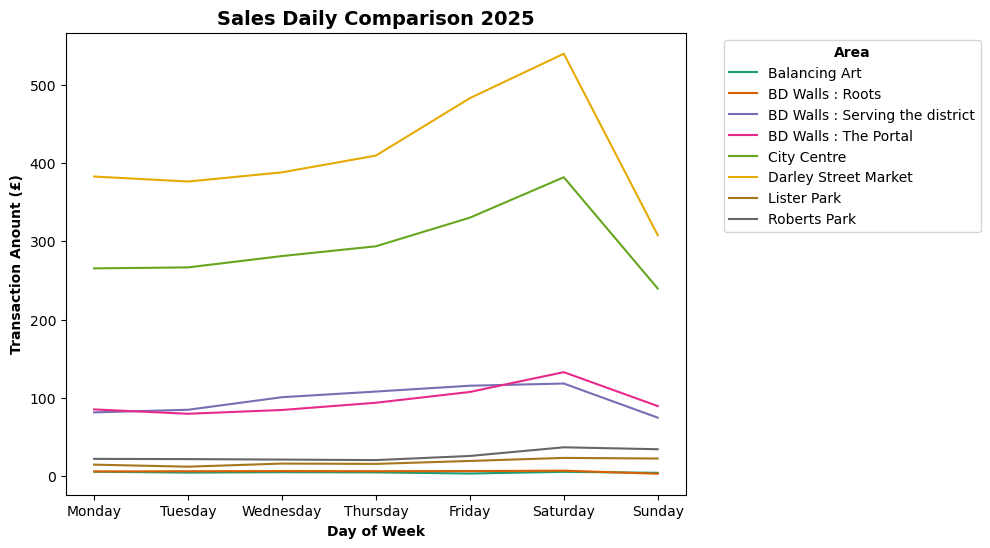

In [648]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(data= df_sales_2025_day, 
             x='Date', 
             y='Transaction Amount', 
             hue='area', 
             legend='full',
            palette='Dark2',
            ax= ax)

# add title
ax.set_title('Sales Daily Comparison 2025', fontsize= 14, weight= 'bold')
ax.set_xlabel('Day of Week', weight= 'bold')
ax.set_ylabel('Transaction Anount (£)', weight= 'bold')

#Move the legend outside of the main figure
ax.legend(title= 'Area',  title_fontproperties={'weight': 'bold'}, bbox_to_anchor=(1.05, 1), loc=2)

Weekly analysis:

In [649]:
#Keep only the daily intervals
df_sales_2025_weekly = df_sales_2025[df_sales_2025['Interval'] == 'weekly']
df_sales_2025_weekly

,area,Interval,Date,Transaction Amount,Industry,Segment
7,Balancing Art,weekly,2024-12-30,6.85,Total Retail,Overall
8,Balancing Art,weekly,2025-01-06,3.71,Total Retail,Overall
9,Balancing Art,weekly,2025-01-13,4.27,Total Retail,Overall
10,Balancing Art,weekly,2025-01-20,6.18,Total Retail,Overall
11,Balancing Art,weekly,2025-01-27,5.76,Total Retail,Overall
...,...,...,...,...,...,...
512,Roberts Park,weekly,2025-10-27,22.85,Total Retail,Overall
513,Roberts Park,weekly,2025-11-03,15.33,Total Retail,Overall
514,Roberts Park,weekly,2025-11-10,33.40,Total Retail,Overall
515,Roberts Park,weekly,2025-11-17,35.95,Total Retail,Overall


In [650]:
#Average over weeks, across areas
df_sales_2025_weekly.describe()

,Transaction Amount
count,384.000000
mean,119.673281
std,145.260325
min,1.190000
25%,8.885000
50%,59.825000
75%,249.010000
max,550.230000


In [651]:
#Create average across weeks for all areas
dfSales_av_2025 = df_sales_2025_weekly.groupby('area')['Transaction Amount'].mean().sort_values()
dfSales_av_2025.head(20)

area
Balancing Art                        4.664583
BD Walls : Roots                     5.863333
Lister Park                         18.023958
Roberts Park                        27.132708
BD Walls : The Portal               96.184583
BD Walls : Serving the district     98.556875
City Centre                        294.368750
Darley Street Market               412.591458
Name: Transaction Amount, dtype: float64

In [652]:
df_sales_2025_weekly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 384 entries, 7 to 516
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                384 non-null    object 
 1   Interval            384 non-null    object 
 2   Date                384 non-null    object 
 3   Transaction Amount  384 non-null    float64
 4   Industry            384 non-null    object 
 5   Segment             384 non-null    object 
dtypes: float64(1), object(5)
memory usage: 21.0+ KB


In [653]:
#Convert dates to datetime
df_sales_2025_weekly['Date'] = pd.to_datetime(df_sales_2025_weekly['Date'])

#Create week number column
df_sales_2025_weekly['week'] = df_sales_2025_weekly['Date'].dt.isocalendar().week
df_sales_2025_weekly

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\2527865177.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_2025_weekly['Date'] = pd.to_datetime(df_sales_2025_weekly['Date'])
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\2527865177.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_2025_weekly['week'] = df_sales_2025_weekly['Date'].dt.isocalendar().week


,area,Interval,Date,Transaction Amount,Industry,Segment,week
7,Balancing Art,weekly,2024-12-30,6.85,Total Retail,Overall,1
8,Balancing Art,weekly,2025-01-06,3.71,Total Retail,Overall,2
9,Balancing Art,weekly,2025-01-13,4.27,Total Retail,Overall,3
10,Balancing Art,weekly,2025-01-20,6.18,Total Retail,Overall,4
11,Balancing Art,weekly,2025-01-27,5.76,Total Retail,Overall,5
...,...,...,...,...,...,...,...
512,Roberts Park,weekly,2025-10-27,22.85,Total Retail,Overall,44
513,Roberts Park,weekly,2025-11-03,15.33,Total Retail,Overall,45
514,Roberts Park,weekly,2025-11-10,33.40,Total Retail,Overall,46
515,Roberts Park,weekly,2025-11-17,35.95,Total Retail,Overall,47


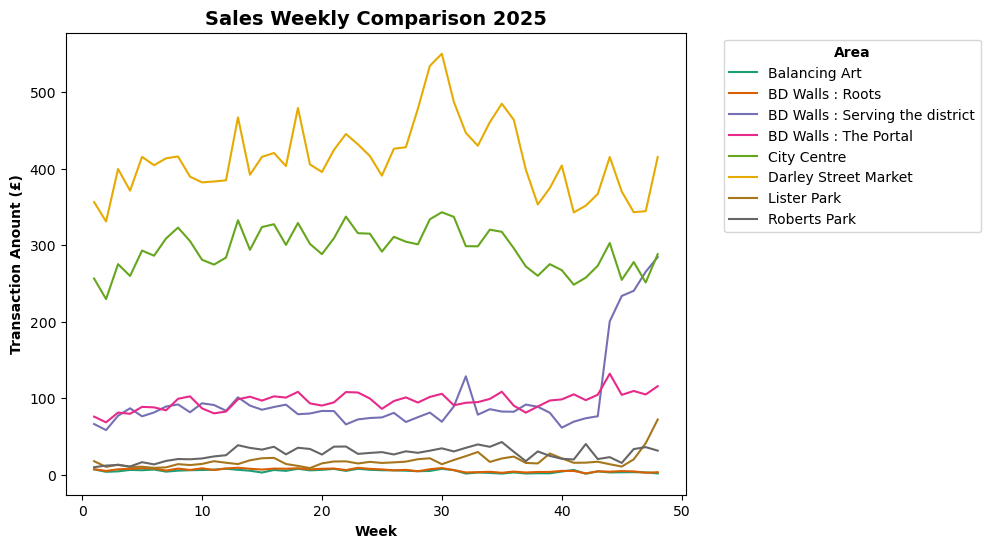

In [654]:
fig, ax = plt.subplots(figsize=(8, 6))

sns.lineplot(data= df_sales_2025_weekly, 
             x= 'week', 
             y='Transaction Amount', 
             hue='area', 
             legend='full',
            palette='Dark2',
            ax= ax)

# add title
ax.set_title('Sales Weekly Comparison 2025', fontsize= 14, weight= 'bold')
ax.set_xlabel('Week', weight= 'bold')
ax.set_ylabel('Transaction Anount (£)', weight= 'bold')

#Move the legend outside of the main figure
ax.legend(title= 'Area',  title_fontproperties={'weight': 'bold'}, bbox_to_anchor=(1.05, 1), loc=2)

Monthly analysis:

In [655]:
#Keep only the daily intervals
df_sales_2025_monthly = df_sales_2025[df_sales_2025['Interval'] == 'monthly']

In [656]:
#Average over months, across areas
df_sales_2025_monthly.describe()

,Transaction Amount
count,88.000000
mean,119.573295
std,145.212608
min,2.020000
25%,10.177500
50%,55.515000
75%,255.845000
max,497.960000


In [657]:
#Create average across weeks for all areas
dfSales_av_2025 = df_sales_2025_monthly.groupby('area')['Transaction Amount'].mean().sort_values()
dfSales_av_2025.head(20)

area
Balancing Art                        4.617273
BD Walls : Roots                     5.837273
Lister Park                         17.820909
Roberts Park                        26.710909
BD Walls : The Portal               96.245455
BD Walls : Serving the district     98.940909
City Centre                        294.262727
Darley Street Market               412.150909
Name: Transaction Amount, dtype: float64

In [658]:
df_sales_2025_monthly.info()

<class 'pandas.core.frame.DataFrame'>
Index: 88 entries, 55 to 527
Data columns (total 6 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   area                88 non-null     object 
 1   Interval            88 non-null     object 
 2   Date                88 non-null     object 
 3   Transaction Amount  88 non-null     float64
 4   Industry            88 non-null     object 
 5   Segment             88 non-null     object 
dtypes: float64(1), object(5)
memory usage: 4.8+ KB


In [660]:
#Convert dates to datetime
df_sales_2025_monthly['Date'] = pd.to_datetime(df_sales_2025_monthly['Date'])

#Create month column
df_sales_2025_monthly['month'] = df_sales_2025_monthly['Date'].dt.month_name()
df_sales_2025_monthly

C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\697647229.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_2025_monthly['Date'] = pd.to_datetime(df_sales_2025_monthly['Date'])
C:\Users\qxnq723\AppData\Local\Temp\ipykernel_32884\697647229.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_sales_2025_monthly['month'] = df_sales_2025_monthly['Date'].dt.month_name()


,area,Interval,Date,Transaction Amount,Industry,Segment,month
55,Balancing Art,monthly,2025-01-01,5.26,Total Retail,Overall,January
56,Balancing Art,monthly,2025-02-01,5.42,Total Retail,Overall,February
57,Balancing Art,monthly,2025-03-01,6.45,Total Retail,Overall,March
58,Balancing Art,monthly,2025-04-01,5.01,Total Retail,Overall,April
59,Balancing Art,monthly,2025-05-01,6.49,Total Retail,Overall,May
...,...,...,...,...,...,...,...
523,Roberts Park,monthly,2025-07-01,30.58,Total Retail,Overall,July
524,Roberts Park,monthly,2025-08-01,38.78,Total Retail,Overall,August
525,Roberts Park,monthly,2025-09-01,24.77,Total Retail,Overall,September
526,Roberts Park,monthly,2025-10-01,22.48,Total Retail,Overall,October


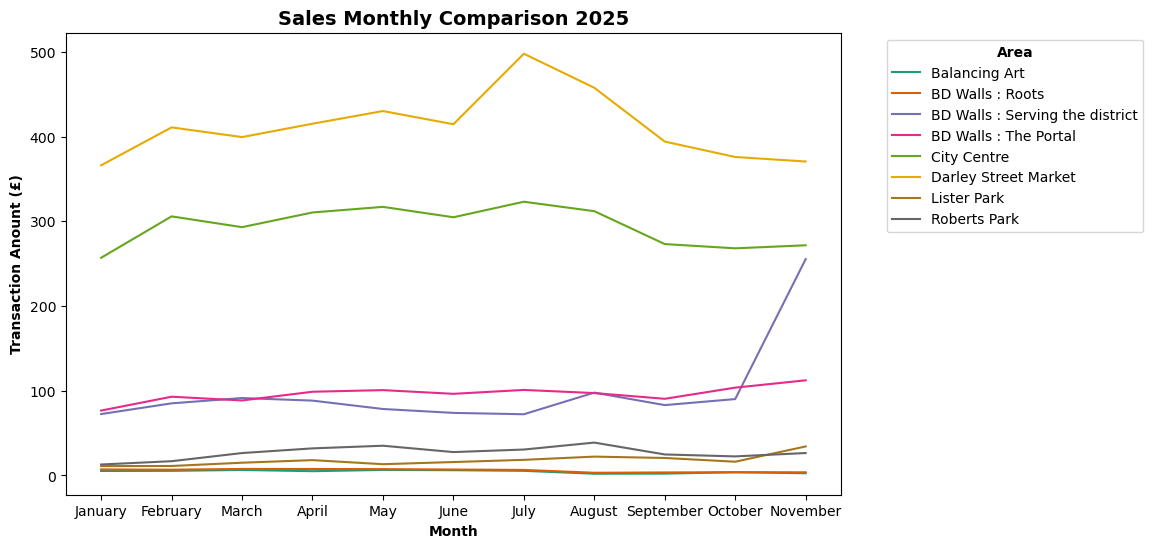

In [663]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.lineplot(data= df_sales_2025_monthly, 
             x= 'month', 
             y='Transaction Amount', 
             hue='area', 
             legend='full',
            palette='Dark2',
            ax= ax)

# add title
ax.set_title('Sales Monthly Comparison 2025', fontsize= 14, weight= 'bold')
ax.set_xlabel('Month', weight= 'bold')
ax.set_ylabel('Transaction Anount (£)', weight= 'bold')

#Move the legend outside of the main figure
ax.legend(title= 'Area',  title_fontproperties={'weight': 'bold'}, bbox_to_anchor=(1.05, 1), loc=2)